# Packaged Optics GUI Backend: Student Guide

This notebook introduces the packaged `optics_gui` backend for work-experience students who know basic Python and are starting to work with a real accelerator-model codebase.

The package turns a clean Python configuration into model outputs such as tune tables, closed-orbit tables, beam envelopes, aperture margins and correction suggestions. It also has an `io` boundary layer for converting external data, such as EPICS archiver-style tables, into the formats expected by the backend.

The examples are split by the planned student tasks:

- EPICS archiver data reading and conversion to backend interface formats.
- Streamlit GUI for orbits.
- Streamlit GUI for envelope/aperture loss prediction.
- Streamlit GUI for working-point programmes.

Full MAD-X model execution is optional and disabled by default. Set `RUN_FULL_MODEL = True` only when `cpymad`, MAD-X and the repository lattice files are available.

## Contents And Group Colour Key

Use these links to jump to the part that matches your task.

| Group | Colour | Main job | Jump |
| --- | --- | --- | --- |
| Setup / package basics | Grey | Learn imports, configs and package structure | [Setup](#setup) |
| EPICS archiver conversion | Blue | Convert controls/archive tables into backend input formats | [Part A](#part-a-epics-archiver-data-conversion) |
| Orbit GUI | Green | Display model or measured orbit data, with optional correction suggestions | [Part B](#part-b-streamlit-gui-for-orbits) |
| Envelope/aperture GUI | Orange | Predict envelope/aperture margins and possible loss locations | [Part C](#part-c-streamlit-gui-for-envelope--aperture-loss-prediction) |
| Working-point GUI | Purple | Display tune programme and resonance information | [Part D](#part-d-streamlit-gui-for-working-point-programmes) |
| Saved outputs | Dark grey | Save and reload result bundles | [Part E](#part-e-saving-and-reloading-results) |

---


## Beginner Physics Glossary

Before using the package, it helps to know the accelerator words that appear in the code, tables and GUIs. This section gives simple definitions. The equations are included so you can connect the physics words to the columns you will see later, such as `x`, `y`, `betx`, `bety`, `dx`, `x_mm`, `aperture_x_m` and `margin_x_m`.

You do not need to memorise these equations. Use them as a map for what the software is calculating.

### ISIS RCS Schematic

The diagram below is page 2 of `ISIS Schematics.pdf`, copied into this repository folder for the student guide. Use it as a visual map for the words in the next sections: the main bending dipoles are yellow in the schematic diagram, and the trim quadrupoles are red in the schematic diagram.

![ISIS RCS schematic](assets/isis_schematic_page-2.png)


### ISIS RCS

ISIS is a neutron and muon facility at Rutherford Appleton Laboratory. The **RCS** is the ISIS **Rapid Cycling Synchrotron**. A synchrotron is a circular accelerator: particles go around many times while magnets guide and focus them in the tranverse $x, y$ plane, and radio frequency electromagnetic cavities accelerate them in the longitudinal (direction of travel) $(s, t)$ plane, where we can think of $s$ as the co-ordinate moving around the RCS like a particle would in a single round trip, or orbit of the accelerator. These particles are eventually smashed against some dense metals in order to `spall` or brute nuclear force the neutrons in their nuclei to be blasted off in nuclear collisions at 84\% of the speed of light...
These neutrons are most useful for imaging materials, our muons are used for things like covid vaccine development, developing better batteries, testing microchips before they go to space, and looking inside ancient artefacts without damaging them. Neutron and muon imagaing is complemtantary to x-ray imaging which is done next door at Diamond light source.

Particles in these simulations are defined by their position and momentum (or similar) co-ordinates in 3 dimensions. We can describe a single particle thus as a vector for example $\underline{particle}_i$:

$$
\underline{particle}_i = \left( x, p_x, y, p_y, s, t\right)
$$

Where
- $x$ is the transverse horizontal position
- $y$ is the transverse vertical position
- $p_x$ is the transverse horizontal momentum (small compared to the large momentum in the $s$ direction)
- $p_y$ is the transverse vertical momentum (small compared to the large momentum in the $s$ direction)
- $s$ is the co-moving co-ordinate in the direction of the beam (or where is should be going :-) )
- $t$ - often interchangeable (with the right unit conversions) with longitudinal momentum offset $\frac{\Delta p}{p}$ (energy difference from the `perfect` beam particle according to hardware programs) - in this case $t$ would be the time offset from the `perfect` or `reference` particle
- $\underline{ }_i$ is just because we usually simulate many particles and each has a numeric label usually denoted by the letter $i$

The particles are protons. The machine (acceleration) cycle is described by time in milliseconds, `cycle_time_ms`. At different times in the cycle, the beam energy, momentum and, magnetic rigidity change. Magnetic rigidity is written $B\rho$ (where $B$ is the magnetic flux density - often called field - and $\rho$ is the bending radius of the main dipole (bending) magnet, yellow in the schematic diagram) and tells us how hard it is to bend the beam:

$$
B\rho = \frac{p}{q}
$$

Here $p$ is particle momentum (in the $s$ direction - it is so much larger than $p_x or p_y$ that it doesn't need a subscript) and $q$ is particle charge. In this package, `cycle_time.py` calculates the beam state for a requested cycle time.

### Lattice, Elements And The Coordinate $s$

The **lattice** is the ordered list of accelerator components: dipoles, quadrupoles, drifts, BPMs, correctors and other elements. The coordinate $s$ means distance along the accelerator, measured in metres.

MAD-X returns a **TWISS table** with one row per element or position. Important columns include:

- `name`: element name;
- `s`: distance around the ring;
- `x`, `y`: closed-orbit position in metres;
- `betx`, `bety`: beta functions;
- `dx`, `dy`: dispersion functions;
- `qx`, `qy`: horizontal and vertical tune values in summary tables.

**Important: Please note that MAD-X computes the trajectory and parameters of the BEAM not a single particle**, and this beam is centred at the path of the reference particle such that $(x,y)=(0,0)$ is the position of the reference particle. In reality this reference path snakes and wiggles through the magnets and particles do not always go through the centre of every magnet - in the simulations they do unless we tell them not to (some of you will work on this).

### Closed Orbit

The **closed orbit** is the path followed by the centre of the beam after it has settled into a repeatable path around the ring. If the magnets are perfectly aligned, the closed orbit should be close to the design path. If magnets are misaligned or correctors are changed, the closed orbit moves.

In the package, orbit tables usually show:

$$
x_{\mathrm{co}}(s), \quad y_{\mathrm{co}}(s)
$$

where `co` means closed orbit. The code also adds millimetre columns:

$$
x_{\mathrm{mm}} = 1000 x, \quad y_{\mathrm{mm}} = 1000 y
$$

This is why GUI plots usually show orbit in millimetres.

### BPMs And Correctors

A **BPM** is a Beam Position Monitor. It measures where the beam is at one location. A **corrector** is a small steering magnet (dipole). It gives the beam a small angular kick. The 'main dipoles' (yellow in the schematic diagram) provide the 10 $\times$ 36$^{\circ}$ bending to maintain an orbit that gets back to the same place and keeps the beam inside the beam pipe (aperture) - at least most of the beam...

A corrector kick is usually written $\theta$ in radians. In controls, operators often set a current $I$ in amps. The package keeps both current and kick values because the GUI needs controls-style values, while MAD-X needs kick values. A simple calibration relation is:

$$
\theta = \frac{C I}{B\rho}
$$

where $C$ is the corrector calibration and $B\rho$ is the beam rigidity. At higher beam rigidity, the same current gives a smaller kick. The reverse conversion is:

$$
I = \frac{\theta B\rho}{C}
$$

A kick changes the orbit around the ring. A simplified linear response is:

$$
\Delta x(s) = \frac{\sqrt{\beta_x(s)\beta_x(s_c)}}{2\sin(\pi Q_x)}\,\theta_c\,\cos\left(|\phi_x(s)-\phi_x(s_c)|-\pi Q_x\right)
$$

Here $s_c$ is the corrector location, $Q_x$ is the horizontal tune, $\beta_x$ is the beta function and $\phi_x$ is the betatron phase. You do not need to calculate this by hand; MAD-X does it. The equation explains why one corrector can affect orbit at many places and also why a kick in one direction may result in an orbit that goes in the other direction at or near that location.

### Tune And Working Point

Particles do small side-to-side oscillations as they travel around the ring. The **tune** $Q$ is the number of oscillations per turn. There is a horizontal tune $Q_x$ and a vertical tune $Q_y$ because the magnets operate on the particles cyclically they oscillate up-down, and left-right, they also oscillate front-back but this is not covered by this GUI as it is complex and requires an individual dedicated code to consider it properly, plus it also has it's own GUI already.

The tune pair in the transverse plane $(Q_x, Q_y)$ is called the **working point**:

$$
\mathrm{working\ point} = (Q_x, Q_y)
$$

Some tune values are risky because they are near **resonance lines**. A simple resonance condition is:

$$
n Q_x + m Q_y = N
$$

where $n$, $m$ and $N$ are integers. The working-point GUI group will mainly work with tune programme tables and resonance-proximity tables. That part does not need orbit, envelope or aperture calculations.

### Beta Functions And Beam Size

The **beta function** describes how strongly the beam size changes around the ring due to the focussing quadrupole magnets. It is not the same as relativistic beta which is related to the particle velocity. In accelerator optics, beta functions are written $\beta_x(s)$ and $\beta_y(s)$ as they are defined as a function of the co-moving co-ordinate $s$ - i.e. they have a different value as $s$ changes.

The RMS beam size from betatron motion is approximately:

$$
\sigma_x(s) = \sqrt{\beta_x(s)\,\epsilon_x}
$$

$$
\sigma_y(s) = \sqrt{\beta_y(s)\,\epsilon_y}
$$

Here $\epsilon_x$ and $\epsilon_y$ are RMS emittances. Emittance describes how spread out the beam is in position and angle. Bigger beta or bigger emittance means a bigger beam.

Smaller beams avoid being lost by hitting the aperture, but they increase the Coulombic repulsion of the particles which ruins their transvserse oscillation frequency (tune) and thus their envelope - aperture relationship. So operating a high intensity accelerator requires a careful balance of beam size with aperture restriction.

### Dispersion And Momentum Spread

Not every particle has exactly the same momentum in it's direction of travel. The fractional momentum error (difference from the `reference` partice) is often written:

$$
\delta = \frac{\Delta p}{p}
$$

The **dispersion** $D_x(s)$ tells us how much the beam position changes when momentum changes. If the beam has momentum spread $\delta$, the horizontal beam size including dispersion is:

$$
\sigma_x(s) = \sqrt{\beta_x(s)\epsilon_x + \left(D_x(s)\delta\right)^2}
$$

The vertical version can include $D_y(s)$ if vertical dispersion is present:

$$
\sigma_y(s) = \sqrt{\beta_y(s)\epsilon_y + \left(D_y(s)\delta\right)^2}
$$

### Normalised And Geometric Emittance

The package supports geometric and normalised RMS emittance $\epsilon$. The normalised emittance $\epsilon_n$ is divided by relativistic (often called Lorentz) beta $\beta_{\mathrm{rel}}$ and gamma $\gamma_{\mathrm{rel}}$: 

$$
\epsilon_n = \beta_{\mathrm{rel}}\gamma_{\mathrm{rel}}\epsilon
$$

so

$$
\epsilon = \frac{\epsilon_n}{\beta_{\mathrm{rel}}\gamma_{\mathrm{rel}}}
$$

Use the package functions rather than doing this conversion manually in a GUI. The GUI should collect user inputs and pass them into `EnvelopeInputs`.

### Envelope

The **beam envelope** is the region around the closed orbit that contains most of the beam. A common display is an $n$-sigma envelope. If $n = 1$, the plotted bounds are:

$$
x_+(s) = x_{\mathrm{co}}(s) + n\sigma_x(s)
$$

$$
x_-(s) = x_{\mathrm{co}}(s) - n\sigma_x(s)
$$

and similarly for $y$. This is why the envelope group needs orbit information: the beam size sits around the closed orbit, not always around zero.

### Aperture And Loss Prediction

The **aperture** is the available physical space for the beam inside the machine. If the beam envelope gets too close to the aperture, particles will likely be lost - causing damage and activation to the hardware. We have dedicated regions where we concentrate beam loss - this is how we control it, by collecting the `halo` particles on collectors (also called collimators).

A simple horizontal clearance margin is:

$$
M_x(s) = A_x(s) - |x_{\mathrm{co}}(s)| - n\sigma_x(s)
$$

where $A_x(s)$ is the horizontal semi-aperture. A negative margin means the chosen envelope is outside the available aperture:

$$
M_x(s) < 0 \quad \Rightarrow \quad \mathrm{possible\ beam\ loss}
$$

The envelope/aperture GUI group should display margins and limiting locations, not recalculate the physics itself.

### Chromaticity

**Chromaticity** describes how tune changes with particle momentum. It is written approximately as:

$$
Q'_x = \frac{dQ_x}{d\delta}, \quad Q'_y = \frac{dQ_y}{d\delta}
$$

where $\delta = \Delta p/p$. In the snapshot tables, chromaticity-related values help describe how the working point changes for particles with slightly different momenta.

### MAD-X, cpymad, EPICS And Streamlit

**MAD-X** is the accelerator modelling program used to calculate optics tables. **cpymad** is the Python interface used by this package to run MAD-X.

**EPICS** is a controls system used at many accelerator facilities. An **EPICS archiver** stores historical controls data, such as corrector currents or magnet settings. The archiver group should convert this data into clean backend input tables.

**Streamlit** is a Python tool for building simple web apps. The Streamlit groups should make pages that collect user choices, call backend functions and display DataFrames/plots. Streamlit pages should not contain physics calculations or custom file parsers.

Important safety rule: this repository is read-only with respect to the real machine. Correction outputs are suggestions for review, not commands to write to controls.

<a id="setup"></a>

---

<div style="border-left: 6px solid #616161; padding: 0.7em 1em; background: #f4f4f4; margin: 1em 0;"><b>Setup and package basics</b></div>


## 0. Setup

If the package has been installed with `pip install -e .`, the imports below should work from anywhere. If not, this notebook adds the repository `src/` folder to `sys.path` when run from the repository checkout.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "12_IO":
    repo_root = repo_root.parents[1]
elif (repo_root / "Dev" / "12_IO").is_dir():
    pass

src_path = repo_root / "src"
if src_path.is_dir() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

RUN_FULL_MODEL = True
RUN_ORBIT_CORRECTION_EXAMPLE = True

print(f"repo_root = {repo_root}")
print(f"RUN_FULL_MODEL = {RUN_FULL_MODEL}")
print(f"RUN_ORBIT_CORRECTION_EXAMPLE = {RUN_ORBIT_CORRECTION_EXAMPLE}")


repo_root = /home/hr/Repositories/optics_gui
RUN_FULL_MODEL = True
RUN_ORBIT_CORRECTION_EXAMPLE = True


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from optics_gui.cycle_time import RCSRamp
from optics_gui.machine_state import MachineState
from optics_gui.correctors import current_to_kick_rad, kick_rad_to_current
from optics_gui.errors import (
    read_error_table,
    summarise_error_table,
    write_zeroed_error_table_copy,
    zero_error_table_magnets,
)
from optics_gui.error_plots import error_table_to_misalignment_offsets, plot_error_table_misalignment_offsets
from optics_gui.tune import (
    build_tune_programme_table,
    build_working_point_table,
    generate_resonance_lines,
    evaluate_resonance_proximity,
    make_tune_diagram_inputs,
)
from optics_gui.snapshot import (
    SnapshotConfig,
    SnapshotSeriesConfig,
    SnapshotOrbitCorrectionConfig,
    build_machine_snapshot,
    build_full_cycle_snapshot_series,
    copy_snapshot_config,
)
from optics_gui.envelope import EnvelopeInputs, plot_envelope, plot_sigma, plot_envelope_comparison
from optics_gui.orbit_correction import (
    bpm_measurements_from_twiss,
    normalise_corrector_selection,
    plot_corrector_suggestions,
    plot_orbit_with_bpm,
)
from optics_gui.aperture import (
    read_source_aperture_csv,
    plot_aperture_envelope_with_margin,
    plot_margin,
)
from optics_gui.tune_plots import plot_tune_diagram_inputs
from optics_gui.io import (
    config_to_record,
    config_from_record,
    corrector_settings_from_table,
    normalise_bpm_table,
    normalise_corrector_table,
    snapshot_configs_from_table,
    write_snapshot_bundle,
    read_run_bundle,
    write_snapshot_config,
    read_snapshot_config,
    series_config_to_record,
    series_config_from_record,
    write_snapshot_series_config,
    read_snapshot_series_config,
)

print("Imports worked")


Imports worked


## 1. The Package In One Picture

Think of the package as three layers:

1. **Inputs**: Python configs and DataFrames. Examples: cycle time, set tune, BPM measurements, corrector currents.
2. **Backend model**: code that builds a machine state and runs MAD-X through `MadxModel`.
3. **Outputs**: pandas DataFrames ready for notebooks, Streamlit tables and plots.

The most important object is `SnapshotConfig`. It describes one machine-model snapshot at one cycle time. Running it gives a `SnapshotResult`, which exposes named tables through `result.table("table_name")`.

In [3]:
basic_config = SnapshotConfig(
    cycle_time_ms=0.0,
    requested_qx=4.31,
    requested_qy=3.83,
    output_dir=str(repo_root / "Dev" / "12_IO" / "student_runs"),
    run_envelope=False,
    run_aperture=False,
)

record = config_to_record(basic_config)
restored = config_from_record(record)

print(record["__type__"])
print(restored.resolved_label())
print(restored.requested_qx, restored.requested_qy)

SnapshotConfig
nominal_0ms
4.31 3.83


The config record above is JSON-compatible. This is useful for GUI forms and saved run manifests. Large numerical tables are not stored inside JSON; they should be kept as CSV or another table format.

## 2. Under The Hood: Beam And Machine State

Most GUI pages should use `SnapshotConfig`, but the package still has the lower-level objects described in the README. This lightweight example shows the beam state and machine state without running MAD-X.

In [4]:
ramp = RCSRamp()
beam_state = ramp.state_at(0.0)

machine_state = MachineState.from_defaults(
    beam_state=beam_state,
    requested_qx=4.31,
    requested_qy=3.83,
)

beam_summary = pd.Series(beam_state.summary_dict(), name="value").to_frame()
machine_summary = pd.Series(
    {
        "cycle_time_ms": machine_state.cycle_time_ms,
        "main_magnet_mode": machine_state.main_magnet_mode,
        "requested_qx": machine_state.requested_qx,
        "requested_qy": machine_state.requested_qy,
        "iqtf_A": machine_state.iqtf_A,
        "iqtd_A": machine_state.iqtd_A,
        "kqtf": machine_state.kqtf,
        "kqtd": machine_state.kqtd,
    },
    name="value",
).to_frame()

display(beam_summary.loc[["cycle_time_ms", "kinetic_energy_MeV", "momentum_GeV_c", "brho_Tm", "beta", "gamma"]])
display(machine_summary)


,value
cycle_time_ms,0.000000
kinetic_energy_MeV,70.000000
momentum_GeV_c,0.369132
brho_Tm,1.231290
beta,0.366103
gamma,1.074605


,value
cycle_time_ms,0.0
main_magnet_mode,rcs_bare
requested_qx,4.31
requested_qy,3.83
iqtf_A,24.492436
iqtd_A,-35.456595
kqtf,0.039724
kqtd,-0.057506


<a id="part-a-epics-archiver-data-conversion"></a>

---

<div style="border-left: 6px solid #1565c0; padding: 0.7em 1em; background: #eef5ff; margin: 1em 0;"><b>Part A: EPICS archiver conversion group</b></div>


# Part A: EPICS Archiver Data Conversion

This group should focus on turning real or exported controls data into backend-ready tables. This part does **not** need to run MAD-X.

The backend expects normalised table shapes. The I/O layer is where column names, units and enabled/disabled masks should be cleaned up.

## A1. Corrector Current Table

A corrector table can come from manual input, a CSV export, or an EPICS archiver query. The backend needs to know the corrector name, plane and current or kick value.

In [5]:
archiver_correctors = pd.DataFrame(
    [
        {"cycle_time_ms": 0.0, "device": "r0hd1", "plane": "H", "current_A": 5},
        {"cycle_time_ms": 0.0, "device": "r0vd1", "plane": "V", "current_A": -8.3},
        {"cycle_time_ms": 0.5, "device": "r0hd1", "plane": "H", "current_A": 10},
    ]
)

settings = corrector_settings_from_table(
    archiver_correctors,
    cycle_time_ms=0.0,
    prefer="currents",
    source="example_archiver_export",
)

settings

SnapshotCorrectorSettings(hd_corrector_kicks_rad=None, vd_corrector_kicks_rad=None, hd_corrector_currents_A={'r0hd1': 5.0}, vd_corrector_currents_A={'r0vd1': -8.3}, prefer='currents', source='example_archiver_export', metadata={'cycle_time_ms': 0.0})

A Streamlit GUI should not do this parsing inside page callbacks. It should call an I/O helper like `corrector_settings_from_table(...)`, then pass the result into a `SnapshotConfig`.

In [6]:
config_with_correctors = copy_snapshot_config(
    basic_config,
    corrector_settings=settings,
)

print(config_with_correctors.corrector_settings.source)
print(config_with_correctors.corrector_settings.hd_corrector_currents_A)

example_archiver_export
{'r0hd1': 5.0}


## A1b. Corrector Calibration: Current To MAD-X Kick

Controls usually talks in amps, while MAD-X uses angular kicks in radians. The package keeps both values so a GUI can display operator-friendly currents and still run the model with MAD-X inputs.

In [7]:
example_corrector = "r0hd1_kick"
example_current_A = 23.2
example_kick_rad = current_to_kick_rad(example_corrector, example_current_A, beam_state)
round_trip_current_A = kick_rad_to_current(example_corrector, example_kick_rad, beam_state)

pd.DataFrame(
    [
        {
            "corrector": example_corrector,
            "current_A": example_current_A,
            "kick_rad": example_kick_rad,
            "kick_mrad": example_kick_rad*1E3,
            "round_trip_current_A": round_trip_current_A,
        }
    ]
)


,corrector,current_A,kick_rad,kick_mrad,round_trip_current_A
0,r0hd1_kick,23.2,0.001573,1.573309,23.2


## A2. BPM Measurement Table

For orbit correction or orbit comparison, BPM measurements need a canonical table with BPM name, plane, measured closed orbit and enabled/disabled state.

In [8]:
raw_bpm_measurements = pd.DataFrame(
    [
        {
            "bpm": "sp0_r0hm1",
            "plane": "H",
            "closed_orbit_mm": 1.2,
            "closed_orbit_mm_err": 0.1,
            "s": 0.730500,
            "enabled": True,
        },
        {
            "bpm": "sp0_r0hm2",
            "plane": "H",
            "closed_orbit_mm": -0.7,
            "closed_orbit_mm_err": 0.1,
            "s": 5.971000,
            "enabled": True,
        },
        {
            "bpm": "sp1_r1hm1",
            "plane": "H",
            "closed_orbit_mm": 0.4,
            "closed_orbit_mm_err": 0.1,
            "s": 22.285282,
            "enabled": True,
        },
        {
            "bpm": "sp1_r1hm2",
            "plane": "H",
            "closed_orbit_mm": 0.0,
            "closed_orbit_mm_err": 0.1,
            "s": 24.416282,
            "enabled": False,
        },
    ]
)

bpm_table = normalise_bpm_table(raw_bpm_measurements)
bpm_table


,bpm,plane,closed_orbit_mm,closed_orbit_mm_err,s,enabled
0,sp0_r0hm1,H,1.2,0.1,0.730500,True
1,sp0_r0hm2,H,-0.7,0.1,5.971000,True
2,sp1_r1hm1,H,0.4,0.1,22.285282,True
3,sp1_r1hm2,H,0.0,0.1,24.416282,False


## A3. Timepoint Programme Table

A working-point or full-cycle programme starts as rows of time and set tunes. The I/O layer turns those rows into a list of `SnapshotConfig` objects.

In [9]:
timepoint_table = pd.DataFrame(
    [
        {"cycle_time_ms": 0.0, "set_qx": 4.31, "set_qy": 3.83, "snapshot_id": "tp_000"},
        {"cycle_time_ms": 0.5, "set_qx": 4.30, "set_qy": 3.82, "snapshot_id": "tp_001", "harmonics": {"D7COS": 0.0005}},
    ]
)

timepoint_configs = snapshot_configs_from_table(timepoint_table, basic_config)

for config in timepoint_configs:
    print(config.snapshot_id, config.cycle_time_ms, config.requested_qx, config.requested_qy, config.harmonics)

tp_000 0.0 4.31 3.83 {}
tp_001 0.5 4.3 3.82 {'D7COS': 0.0005}


<a id="part-b-streamlit-gui-for-orbits"></a>

---

<div style="border-left: 6px solid #2e7d32; padding: 0.7em 1em; background: #eef8f0; margin: 1em 0;"><b>Part B: orbit GUI group</b></div>


# Part B: Streamlit GUI For Orbits

This group needs to know how to build one snapshot and read orbit tables. It may also use BPM and corrector tables if correction suggestions are later added.

For a first orbit GUI, focus on:

- user chooses cycle time and set tunes;
- user chooses one orbit source mode;
- backend builds a snapshot or normalises a measured-orbit table;
- GUI displays `orbit`, `orbit_summary`, and optionally selected BPM/corrector tables;
- GUI plots `s` against `x_mm` and `y_mm`.

Envelope/aperture and working-point programme details are not required for the orbit-only GUI.

There are now three orbit modes to keep separate:

1. **Nominal model orbit**: run the model with no error table.
2. **Error-table model orbit**: load a repository-local MAD-X error table first, then show the distorted model orbit.
3. **Measured orbit**: load BPM measurements from a file or archiver export and display/correct those measurements.

For the student project, correction should apply to **one** source of orbit distortion only. Do not combine an error-table model orbit and a measured orbit in the same correction request. Combining both correctly requires extra matching and subtracting reference orbits, so it should be a later expert workflow.


<div style="border-left: 6px solid #2e7d32; padding: 0.7em 1em; background: #eef8f0; margin: 1em 0;">
<b>Orbit group rule:</b> choose exactly one source mode for a correction workflow: nominal/error-table model orbit <i>or</i> measured BPM orbit. Do not correct both together in the first Streamlit GUI.
</div>


## B1. Shared Orbit Snapshot Settings

These settings are common to nominal and error-table model orbits. They define cycle time, tunes, lattice folder and output folder. Envelope/aperture are disabled here because this group is only handling orbits.


In [10]:
orbit_base_config = SnapshotConfig(
    cycle_time_ms=0.0,
    requested_qx=4.31,
    requested_qy=3.83,
    lattice_folder=str(repo_root / "Dev" / "Lattice_Files" / "00_Simplified_Lattice"),
    output_dir=str(repo_root / "Dev" / "12_IO" / "student_runs" / "orbit"),
    run_envelope=False,
    run_aperture=False,
)

print(orbit_base_config.resolved_label())


nominal_0ms


## B2. Mode 1: Nominal Model Orbit

This is the simplest model orbit. It does not load an error table and does not use measured BPM data. Although in the laboratory frame (where we are), the beam trajectory snakes through magnets and has many bumps and wobbles, at this stage the code assumes the perfect path through magnet centres. The co-ordinates are chosen as co-moving, such that in the code s=0 is the trajectory of the reference particle and looks like a perfectly straight line. If we used lab co-ordinates things would be a massive headache as the trajectory would look like a circular roller-coaster.

In [11]:
nominal_orbit_config = copy_snapshot_config(
    orbit_base_config,
    snapshot_id="student_nominal_orbit",
    label="student nominal orbit",
    error_table_paths=[],
    orbit_correction_configs=[],
)

if RUN_FULL_MODEL:
    nominal_orbit_snapshot = build_machine_snapshot(nominal_orbit_config)
    orbit_snapshot = nominal_orbit_snapshot
    display(nominal_orbit_snapshot.table("orbit_summary"))
    display(nominal_orbit_snapshot.table("orbit").head())
else:
    print("Set RUN_FULL_MODEL = True to run MAD-X and create nominal_orbit_snapshot.")
    print("The Streamlit orbit GUI will mainly consume: snapshot.table('orbit') and snapshot.table('orbit_summary').")


,n_rows,max_abs_x_m,max_abs_y_m,rms_x_m,rms_y_m,max_orbit_radius_m,max_abs_x_mm,max_abs_y_mm,rms_x_mm,rms_y_mm,max_orbit_radius_mm
0,586,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,name,keyword,s,x,y,px,py,x_mm,y_mm,orbit_radius_m,orbit_radius_mm
#s,synchrotron$start:1,marker,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sp0_datum,sp0_datum:1,marker,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sp0_dipfr8,sp0_dipfr8:1,sbend,0.16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sp0_dipfr9,sp0_dipfr9:1,sbend,0.36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sp0_dipfr10,sp0_dipfr10:1,sbend,0.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


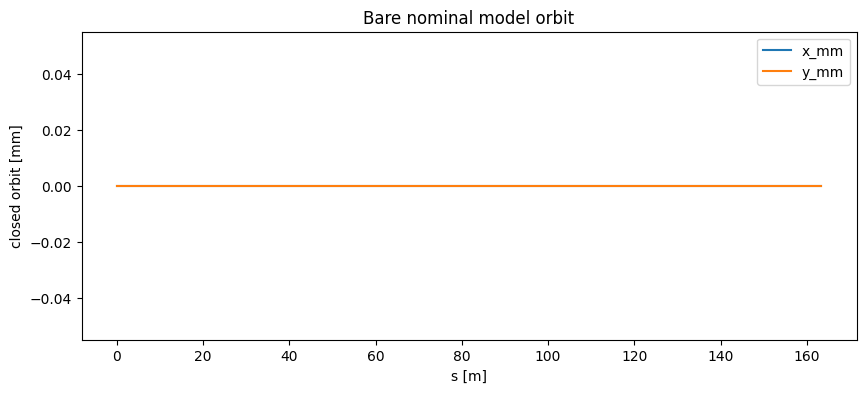

In [12]:
# Bare nominal model orbit plot
if RUN_FULL_MODEL:
    ax = nominal_orbit_snapshot.table("orbit").plot(x="s", y=["x_mm", "y_mm"], figsize=(10, 4))
    ax.set_xlabel("s [m]")
    ax.set_ylabel("closed orbit [mm]")
    ax.set_title("Bare nominal model orbit")
else:
    print("Bare orbit plot skipped because RUN_FULL_MODEL is False.")


## B3. Mode 2: Error-Table Model Orbit

This mode starts from a model error table which is useful for showing what a known survey/misalignment table does to the model orbit.  The survey/misalignment table represents measurements of the accelerator magnet positions (which are not perfectly in agreement with the design positions). Misalignments affect the roller-coasted like trajectory), and move it away from that of the perfect reference trajectory. The orbit is still closed, but it becomes perturbed in a predictable way, as we know how th bending and focusing magnets produce a force on the particle beam.

The GUI should present this as a separate mode from measured-orbit correction. The user picks an error table path, the backend applies it, and the GUI displays the resulting model orbit.


## B3a. Error-Table Inspection Before Running The Model

Before using an error table in a model run, inspect it as data. These helpers do not run MAD-X; they just load and summarise the MAD-X/TFS table.

In [13]:
jan26_error_table = repo_root / "Dev" / "Error_Tables" / "jan26_survey_corrected.tfs"

jan26_errors = read_error_table(jan26_error_table)
jan26_error_summary = summarise_error_table(jan26_errors)

print(jan26_error_table)
print("rows:", jan26_error_summary["n_rows"])
print("unique names:", jan26_error_summary["n_unique_names"])
print("max |dx| [m]:", jan26_error_summary["max_abs_dx"])
print("max |dy| [m]:", jan26_error_summary["max_abs_dy"])

display(jan26_errors[["name", "dx", "dy", "dphi", "dtheta", "dpsi"]].head())


/home/hr/Repositories/optics_gui/Dev/Error_Tables/jan26_survey_corrected.tfs
rows: 38
unique names: 38
max |dx| [m]: 0.003981439575
max |dy| [m]: 0.000973


,name,dx,dy,dphi,dtheta,dpsi
0,SP0_QD,0.000217,0.000286,-0.000355,-0.000016,0.000000
1,SP0_QF,0.000091,0.000133,0.000526,0.000107,0.000000
2,SP0_QDS,-0.000693,0.000159,0.000332,0.000604,0.000000
3,SP1_DIP,-0.000241,-0.000146,0.000055,-0.000509,0.000058
4,SP1_QD,-0.003981,0.000206,-0.000061,0.000086,0.000000


The same loaded error table can be displayed as magnet misalignment offsets versus `s`. This is the direct GUI view of the survey/misalignment table, before any orbit calculation is run.


,name,magnet,S_centre,x_offset_mm,x_angle_mrad
0,SP0_QD,QD 0,3.401000,0.216558,-0.016348
1,SP0_QF,QF 0,4.846000,0.091379,0.107250
2,SP0_QDS,QC 0,10.950000,-0.692949,0.603844
3,SP1_DIP,Dipole 1,13.746282,-0.241158,-0.509142
4,SP1_QD,QD 1,19.737282,-3.981440,0.085697


,name,magnet,S_centre,y_offset_mm,y_angle_mrad
0,SP0_QD,QD 0,3.401000,0.2860,0.354533
1,SP0_QF,QF 0,4.846000,0.1330,-0.526316
2,SP0_QDS,QC 0,10.950000,0.1585,-0.331593
3,SP1_DIP,Dipole 1,13.746282,-0.1455,-0.054925
4,SP1_QD,QD 1,19.737282,0.2055,0.060893


(<Figure size 1200x500 with 1 Axes>,
 <Axes: title={'center': 'Jan26 vertical magnet misalignments'}, xlabel='S [m]', ylabel='Offset [mm]'>)

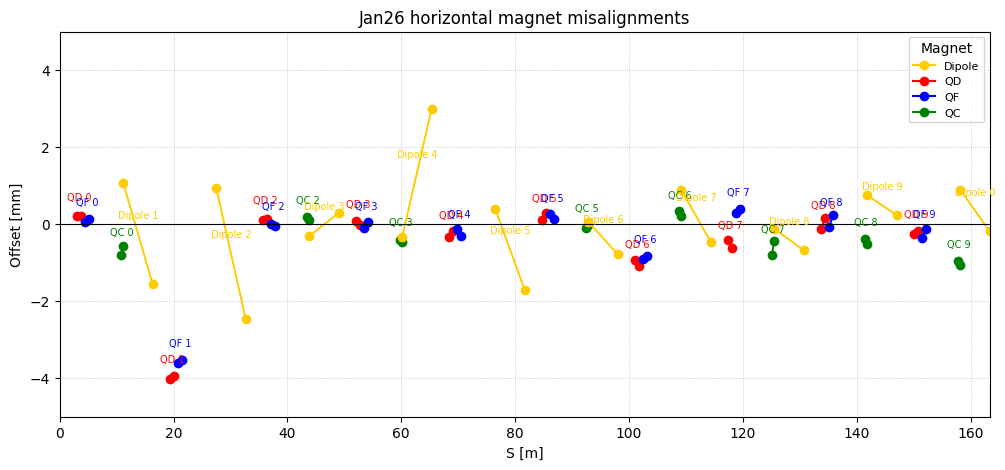

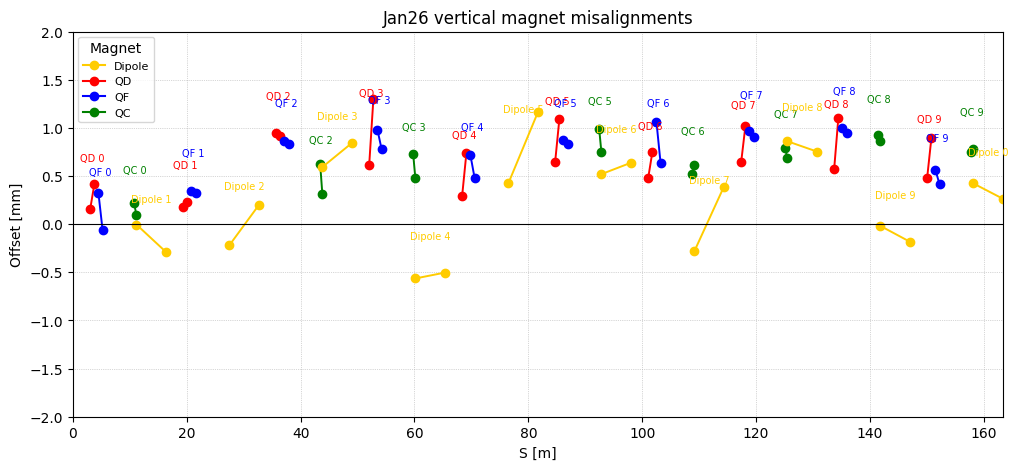

In [14]:
jan26_horizontal_misalignments = error_table_to_misalignment_offsets(jan26_errors, plane="x")
jan26_vertical_misalignments = error_table_to_misalignment_offsets(jan26_errors, plane="y")

display(
    jan26_horizontal_misalignments[
        ["name", "magnet", "S_centre", "offset_centre", "angle"]
    ].rename(columns={"offset_centre": "x_offset_mm", "angle": "x_angle_mrad"}).head()
)
display(
    jan26_vertical_misalignments[
        ["name", "magnet", "S_centre", "offset_centre", "angle"]
    ].rename(columns={"offset_centre": "y_offset_mm", "angle": "y_angle_mrad"}).head()
)

plot_error_table_misalignment_offsets(
    jan26_errors,
    plane="x",
    title="Jan26 horizontal magnet misalignments",
)
plot_error_table_misalignment_offsets(
    jan26_errors,
    plane="y",
    title="Jan26 vertical magnet misalignments",
)


## B3b. Manual Error-Table Edits

Visual inspection often shows magnets or families whose survey-derived values should be excluded from a trial model. The QC values are a common case: these magnets do not have normal survey markers, and the measurement uses a custom jig placed on top of the magnet, so the QC alignment estimate is usually less reliable than the dipole/QD/QF measurements.

Do not overwrite the source survey table. Make a timestamped copy, zero the selected rows in the copy, and use that copied file in MAD-X.


single magnet zeroed: ['SP0_QDS']
single magnet file: /home/hr/Repositories/optics_gui/madx_runs/student_error_table_edits/jan26_survey_corrected_sp0_qc_zeroed_20260713_132330.tfs
named magnets file: /home/hr/Repositories/optics_gui/madx_runs/student_error_table_edits/jan26_survey_corrected_named_magnets_zeroed_20260713_132330.tfs
QC family file: /home/hr/Repositories/optics_gui/madx_runs/student_error_table_edits/jan26_survey_corrected_all_qc_zeroed_20260713_132331.tfs
QC rows zeroed: ['SP0_QDS', 'SP2_QDS', 'SP3_QDS', 'SP5_QDS', 'SP6_QDS', 'SP7_QDS', 'SP8_QDS', 'SP9_QDS']


,name,dx,dy,dphi,dtheta,dpsi
2,SP0_QDS,0.0,0.0,0.0,0.0,0.0
9,SP2_QDS,0.0,0.0,0.0,0.0,0.0
13,SP3_QDS,0.0,0.0,0.0,0.0,0.0
20,SP5_QDS,0.0,0.0,0.0,0.0,0.0
24,SP6_QDS,0.0,0.0,0.0,0.0,0.0


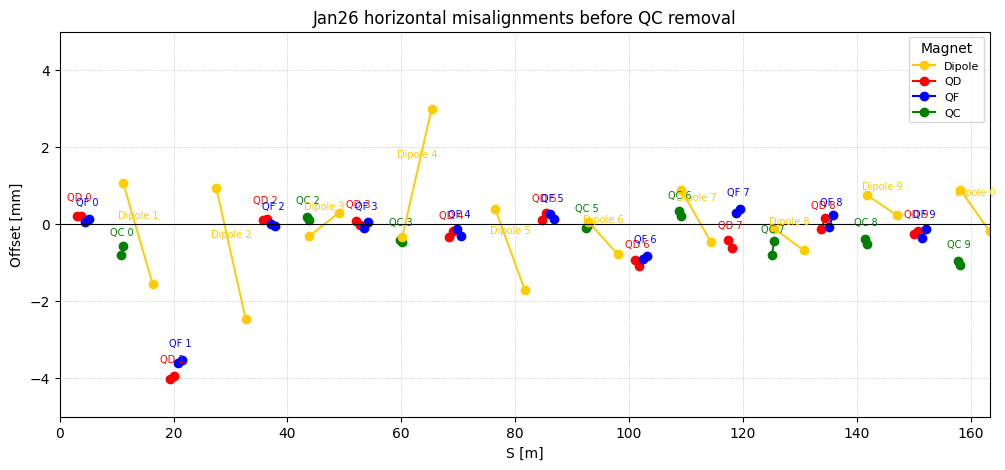

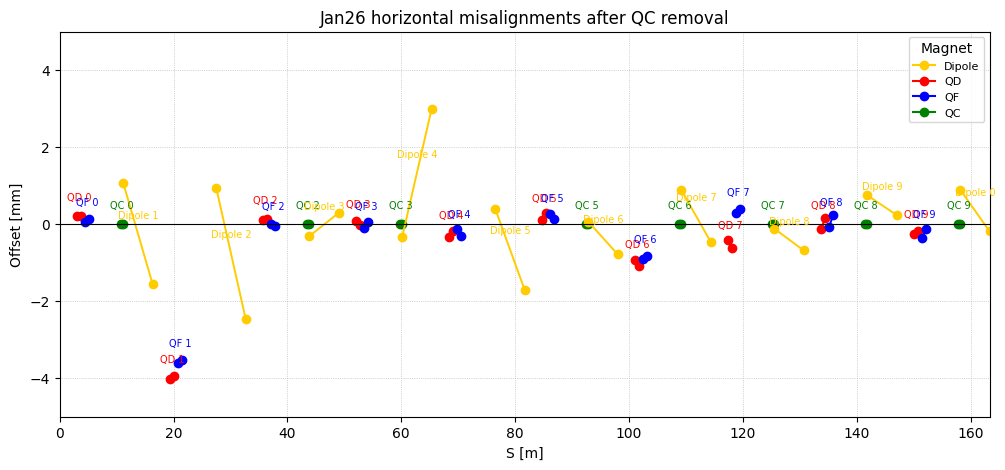

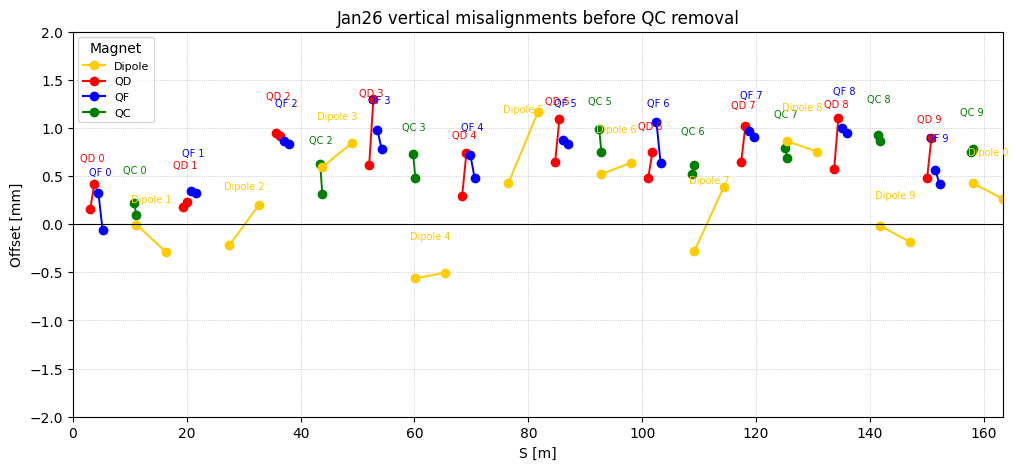

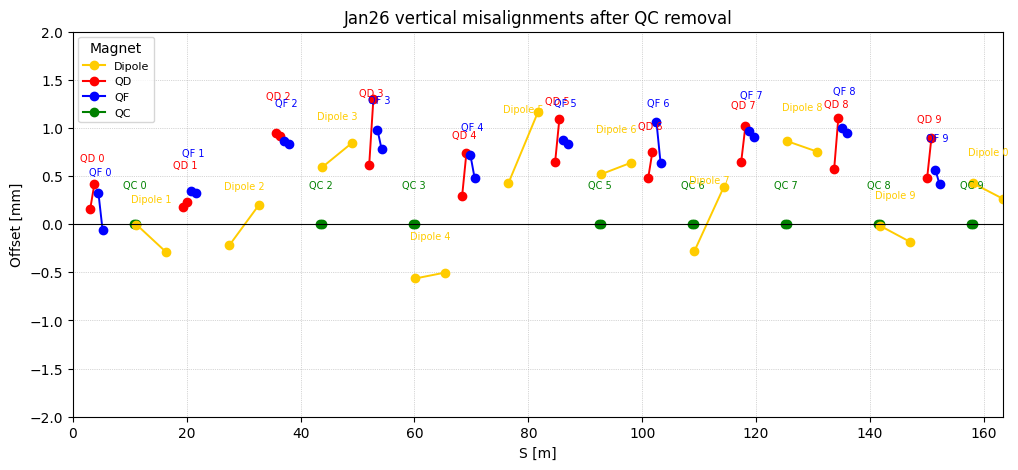

In [15]:
edited_error_table_dir = repo_root / "madx_runs" / "student_error_table_edits"

# One-off DataFrame edit, useful for previewing exactly what will be zeroed.
sp0_qds_zeroed, sp0_qds_names = zero_error_table_magnets(
    jan26_errors,
    names=["SP0_QDS"],
    return_zeroed_names=True,
)
print("single magnet zeroed:", sp0_qds_names)

# Timestamped files for MAD-X: single magnet, multiple named magnets, and a full family.
single_magnet_edit = write_zeroed_error_table_copy(
    jan26_error_table,
    output_dir=edited_error_table_dir,
    names=["SP0_QDS"],
    suffix="sp0_qc_zeroed",
    return_table=True,
)
named_magnets_edit = write_zeroed_error_table_copy(
    jan26_error_table,
    output_dir=edited_error_table_dir,
    names=["SP0_QD", "SP1_QF", "SP3_DIP"],
    suffix="named_magnets_zeroed",
    return_table=True,
)
qc_family_edit = write_zeroed_error_table_copy(
    jan26_error_table,
    output_dir=edited_error_table_dir,
    families=["QC"],
    suffix="all_qc_zeroed",
    return_table=True,
)

print("single magnet file:", single_magnet_edit["path"])
print("named magnets file:", named_magnets_edit["path"])
print("QC family file:", qc_family_edit["path"])
print("QC rows zeroed:", qc_family_edit["zeroed_names"])

# Visual check: original table versus the all-QC-zeroed copy, in both planes.
plot_error_table_misalignment_offsets(
    jan26_errors,
    plane="x",
    title="Jan26 horizontal misalignments before QC removal",
)
plot_error_table_misalignment_offsets(
    qc_family_edit["table"],
    plane="x",
    title="Jan26 horizontal misalignments after QC removal",
)
plot_error_table_misalignment_offsets(
    jan26_errors,
    plane="y",
    title="Jan26 vertical misalignments before QC removal",
)
plot_error_table_misalignment_offsets(
    qc_family_edit["table"],
    plane="y",
    title="Jan26 vertical misalignments after QC removal",
)

display(
    qc_family_edit["table"]
    .loc[qc_family_edit["table"]["name"].str.endswith("_QDS"), ["name", "dx", "dy", "dphi", "dtheta", "dpsi"]]
    .head()
)


In [16]:
jan26_error_table = repo_root / "Dev" / "Error_Tables" / "jan26_survey_corrected.tfs"

error_orbit_config = copy_snapshot_config(
    orbit_base_config,
    snapshot_id="student_error_table_orbit",
    label="student error-table orbit",
    error_table_paths=[str(jan26_error_table)],
    orbit_correction_configs=[],
)

print(jan26_error_table)
print("exists:", jan26_error_table.is_file())

if RUN_FULL_MODEL:
    error_orbit_snapshot = build_machine_snapshot(error_orbit_config)
    orbit_snapshot = error_orbit_snapshot
    display(error_orbit_snapshot.table("orbit_summary"))
    display(error_orbit_snapshot.table("orbit").head())
else:
    print("Set RUN_FULL_MODEL = True to run MAD-X with the error table.")
    print("This mode displays the model orbit after applying error_table_paths.")


/home/hr/Repositories/optics_gui/Dev/Error_Tables/jan26_survey_corrected.tfs
exists: True


,n_rows,max_abs_x_m,max_abs_y_m,rms_x_m,rms_y_m,max_orbit_radius_m,max_abs_x_mm,max_abs_y_mm,rms_x_mm,rms_y_mm,max_orbit_radius_mm
0,586,0.008839,0.008486,0.003027,0.004241,0.009224,8.838513,8.486098,3.026537,4.241288,9.224284


,name,keyword,s,x,y,px,py,x_mm,y_mm,orbit_radius_m,orbit_radius_mm
#s,synchrotron$start:1,marker,0.00,-0.000621,0.005098,-0.000114,0.001080,-0.620929,5.098091,0.005136,5.135765
sp0_datum,sp0_datum:1,marker,0.00,-0.000621,0.005098,-0.000114,0.001080,-0.620929,5.098091,0.005136,5.135765
sp0_dipfr8,sp0_dipfr8:1,sbend,0.16,-0.000639,0.005272,-0.000113,0.001090,-0.639139,5.271691,0.005310,5.310294
sp0_dipfr9,sp0_dipfr9:1,sbend,0.36,-0.000662,0.005490,-0.000113,0.001089,-0.661738,5.489523,0.005529,5.529264
sp0_dipfr10,sp0_dipfr10:1,sbend,0.39,-0.000665,0.005522,-0.000113,0.001089,-0.665130,5.522182,0.005562,5.562094


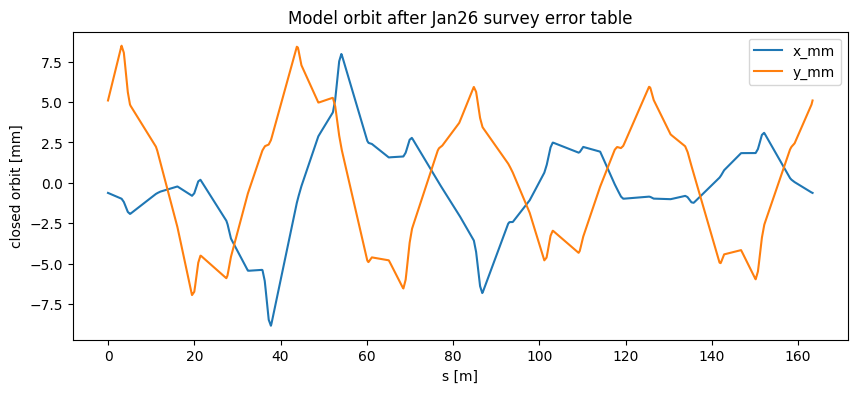

In [17]:
# Jan26 error-table model orbit plot
if RUN_FULL_MODEL:
    ax = error_orbit_snapshot.table("orbit").plot(x="s", y=["x_mm", "y_mm"], figsize=(10, 4))
    ax.set_xlabel("s [m]")
    ax.set_ylabel("closed orbit [mm]")
    ax.set_title("Model orbit after Jan26 survey error table")
else:
    print("Error-table orbit plot skipped because RUN_FULL_MODEL is False.")


The practical check is to run MAD-X with the edited file and verify that the closed orbit changes. Removing all QCs should change the orbit relative to the full Jan26 table; if it does not, the edited file probably was not the file actually read by MAD-X.


,max_abs_delta_x_mm,max_abs_delta_y_mm,rms_delta_x_mm,rms_delta_y_mm
0,0.857421,3.371791,0.258625,1.30987


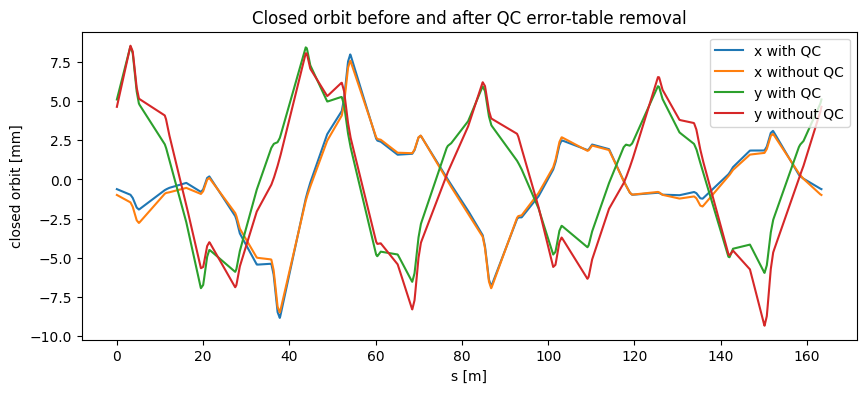

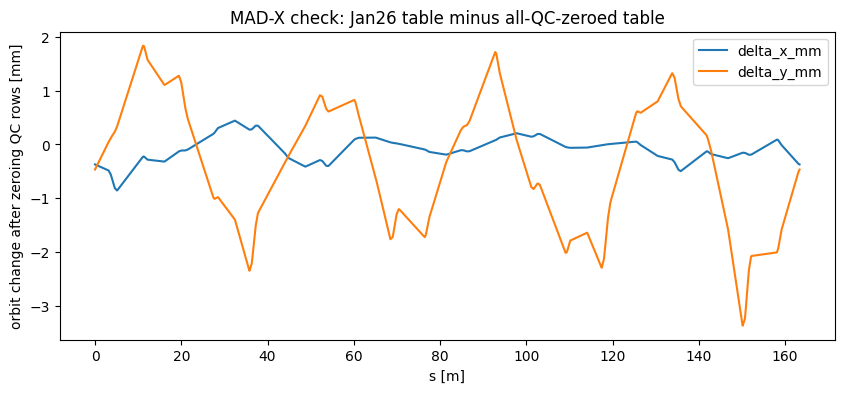

In [18]:
if RUN_FULL_MODEL:
    qc_zeroed_orbit_config = copy_snapshot_config(
        orbit_base_config,
        snapshot_id="student_error_table_orbit_without_qc",
        label="student error-table orbit without QC rows",
        error_table_paths=[qc_family_edit["path"]],
        orbit_correction_configs=[],
    )
    qc_zeroed_orbit_snapshot = build_machine_snapshot(qc_zeroed_orbit_config)

    original_orbit = error_orbit_snapshot.table("orbit")[["name", "s", "x_mm", "y_mm"]]
    qc_zeroed_orbit = qc_zeroed_orbit_snapshot.table("orbit")[["name", "x_mm", "y_mm"]]
    qc_orbit_difference = original_orbit.merge(
        qc_zeroed_orbit,
        on="name",
        suffixes=("_with_qc", "_without_qc"),
    )
    qc_orbit_difference["delta_x_mm"] = qc_orbit_difference["x_mm_without_qc"] - qc_orbit_difference["x_mm_with_qc"]
    qc_orbit_difference["delta_y_mm"] = qc_orbit_difference["y_mm_without_qc"] - qc_orbit_difference["y_mm_with_qc"]

    qc_orbit_difference_summary = pd.DataFrame(
        [
            {
                "max_abs_delta_x_mm": qc_orbit_difference["delta_x_mm"].abs().max(),
                "max_abs_delta_y_mm": qc_orbit_difference["delta_y_mm"].abs().max(),
                "rms_delta_x_mm": (qc_orbit_difference["delta_x_mm"] ** 2).mean() ** 0.5,
                "rms_delta_y_mm": (qc_orbit_difference["delta_y_mm"] ** 2).mean() ** 0.5,
            }
        ]
    )
    display(qc_orbit_difference_summary)
    assert qc_orbit_difference_summary[["max_abs_delta_x_mm", "max_abs_delta_y_mm"]].to_numpy().max() > 0.0

    orbit_before_after = qc_orbit_difference[[
        "s",
        "x_mm_with_qc",
        "x_mm_without_qc",
        "y_mm_with_qc",
        "y_mm_without_qc",
    ]].rename(
        columns={
            "x_mm_with_qc": "x with QC",
            "x_mm_without_qc": "x without QC",
            "y_mm_with_qc": "y with QC",
            "y_mm_without_qc": "y without QC",
        }
    )
    ax_before_after = orbit_before_after.plot(
        x="s",
        y=["x with QC", "x without QC", "y with QC", "y without QC"],
        figsize=(10, 4),
    )
    ax_before_after.set_xlabel("s [m]")
    ax_before_after.set_ylabel("closed orbit [mm]")
    ax_before_after.set_title("Closed orbit before and after QC error-table removal")

    ax = qc_orbit_difference.plot(x="s", y=["delta_x_mm", "delta_y_mm"], figsize=(10, 4))
    ax.set_xlabel("s [m]")
    ax.set_ylabel("orbit change after zeroing QC rows [mm]")
    ax.set_title("MAD-X check: Jan26 table minus all-QC-zeroed table")
else:
    print("QC-zeroed orbit comparison skipped because RUN_FULL_MODEL is False.")


## B4. Mode 3: Measured Orbit Table

This mode starts from measured BPM data, for example from an EPICS archiver export. It does not need an error table. The first job is to normalise the measured data into the backend BPM table format.

A measured orbit table is not the same thing as a full TWISS orbit table. BPM data only exists at monitor locations, while a model orbit table has values around the full lattice.


In [19]:
# Example measured orbit table using real BPM-style names and known s positions.
# The earlier dummy names produced NaN s/error columns because those optional columns were not supplied.
# The backend can resolve BPM labels against TWISS names with resolve_bpm_to_twiss_name(...),
# and bpm_measurements_from_twiss(...) is the safest way to get real names and s positions from a model table.
if RUN_FULL_MODEL:
    measured_bpm_table = bpm_measurements_from_twiss(nominal_orbit_snapshot.table("twiss"), plane="H").head(8)
    measured_bpm_table = measured_bpm_table.copy()
    measured_bpm_table["closed_orbit_mm"] = [0.8, -0.6, 1.1, -0.9, 0.4, -0.3, 0.7, -0.5]
else:
    raw_measured_orbit = pd.DataFrame(
        [
            {"bpm": "sp0_r0hm1", "plane": "H", "closed_orbit_mm": 0.8, "closed_orbit_mm_err": 0.1, "s": 0.730500, "enabled": True},
            {"bpm": "sp0_r0hm2", "plane": "H", "closed_orbit_mm": -0.6, "closed_orbit_mm_err": 0.1, "s": 5.971000, "enabled": True},
            {"bpm": "sp1_r1hm1", "plane": "H", "closed_orbit_mm": 1.1, "closed_orbit_mm_err": 0.1, "s": 22.285282, "enabled": True},
            {"bpm": "sp1_r1hm2", "plane": "H", "closed_orbit_mm": -0.9, "closed_orbit_mm_err": 0.1, "s": 24.416282, "enabled": True},
        ]
    )
    measured_bpm_table = normalise_bpm_table(raw_measured_orbit)

measured_bpm_table


,bpm,plane,closed_orbit_mm,closed_orbit_mm_err,s,enabled
0,sp0_r0hm1,H,0.8,0.1,0.730500,True
1,sp0_r0hm2,H,-0.6,0.1,5.971000,True
2,sp1_r1hm1,H,1.1,0.1,22.285282,True
3,sp1_r1hm2,H,-0.9,0.1,24.416282,True
4,sp2_r2hm1,H,0.4,0.1,33.403064,True
5,sp2_r2hm2,H,-0.3,0.1,38.643564,True
6,sp3_r3hm1,H,0.7,0.1,54.979846,True
7,sp4_r4hm2,H,-0.5,0.1,71.316128,True


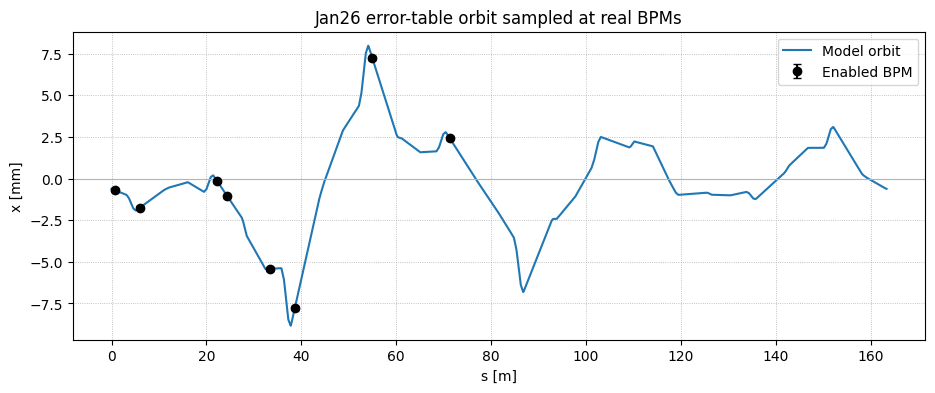

In [20]:
# Jan26 error-table BPM sampling plot
if RUN_FULL_MODEL:
    jan26_bpm_match = bpm_measurements_from_twiss(error_orbit_snapshot.table("twiss"), plane="H").head(8)
    ax = plot_orbit_with_bpm(
        error_orbit_snapshot.table("twiss"),
        jan26_bpm_match,
        plane="H",
        title="Jan26 error-table orbit sampled at real BPMs",
    )
else:
    jan26_bpm_match = measured_bpm_table.copy()
    print("Jan26 BPM sampling plot skipped because RUN_FULL_MODEL is False.")


## B5. Optional Read-Only Correction Suggestions

This example takes the Jan26 error-table model orbit as the orbit to correct. The backend samples BPM-like measurements from that distorted model orbit, runs MAD-X `CORRECT` against the nominal model, and reports current suggestions for the selected steering correctors.

This is still read-only: it produces suggested currents and plots, but does not write anything to the real machine.


In [21]:
def select_correctors_for_demo(plane, corrector_names):
    correctors = normalise_corrector_selection(plane=plane)
    selected = {name.lower() for name in corrector_names}
    correctors["enabled"] = correctors["corrector"].str.lower().isin(selected)
    return correctors

if RUN_FULL_MODEL and RUN_ORBIT_CORRECTION_EXAMPLE:
    error_orbit_bpm_h = bpm_measurements_from_twiss(error_orbit_snapshot.table("twiss"), plane="H")
    error_orbit_bpm_v = bpm_measurements_from_twiss(error_orbit_snapshot.table("twiss"), plane="V")

    h_correctors = select_correctors_for_demo("H", ["r0hd1_kick", "r3hd1_kick", "r5hd1_kick", "r9hd1_kick"])
    v_correctors = select_correctors_for_demo("V", ["r0vd1_kick", "r3vd1_kick", "r5vd1_kick", "r9vd1_kick"])

    error_orbit_correction_config = copy_snapshot_config(
        orbit_base_config,
        snapshot_id="student_error_table_orbit_correction",
        label="student error-table orbit correction",
        error_table_paths=[],
        orbit_correction_configs=[
            SnapshotOrbitCorrectionConfig(
                plane="H",
                label="horizontal_error_table_orbit",
                bpm_measurements=error_orbit_bpm_h,
                correctors=h_correctors,
            ),
            SnapshotOrbitCorrectionConfig(
                plane="V",
                label="vertical_error_table_orbit",
                bpm_measurements=error_orbit_bpm_v,
                correctors=v_correctors,
            ),
        ],
    )
    error_orbit_correction_snapshot = build_machine_snapshot(error_orbit_correction_config)
    display(error_orbit_correction_snapshot.table("orbit_correction_summary"))
    display(error_orbit_correction_snapshot.table("orbit_correction_correctors"))
else:
    print("Correction example skipped. Keep RUN_FULL_MODEL and RUN_ORBIT_CORRECTION_EXAMPLE true to run it.")


,snapshot_id,correction_label,plane,read_only,workflow,n_seed_bpm,n_seed_fit_knobs,n_enabled_correctors,before_n_monitor,before_rms_orbit_mm,before_max_abs_orbit_mm,before_mean_orbit_mm,after_n_monitor,after_rms_orbit_mm,after_max_abs_orbit_mm,after_mean_orbit_mm,rms_change_mm
0,student_error_table_orbit_correction,horizontal_error_table_orbit,H,True,bpm_match_then_madx_correct,16,10,4,16,0.0,0.0,0.0,16,0.0,0.0,0.0,0.0
1,student_error_table_orbit_correction,vertical_error_table_orbit,V,True,bpm_match_then_madx_correct,20,10,4,20,0.0,0.0,0.0,20,0.0,0.0,0.0,0.0


,snapshot_id,correction_label,corrector,plane,superperiod,enabled,initial_kick_rad,matched_kick_rad,delta_kick_rad,delta_kick_mrad,delta_current_A
0,student_error_table_orbit_correction,horizontal_error_table_orbit,r0hd1_kick,H,0,True,0.0,0.0,0.0,0.0,0.0
1,student_error_table_orbit_correction,horizontal_error_table_orbit,r2hd1_kick,H,2,False,0.0,0.0,0.0,0.0,0.0
2,student_error_table_orbit_correction,horizontal_error_table_orbit,r3hd1_kick,H,3,True,0.0,0.0,0.0,0.0,0.0
3,student_error_table_orbit_correction,horizontal_error_table_orbit,r4hd1_kick,H,4,False,0.0,0.0,0.0,0.0,0.0
4,student_error_table_orbit_correction,horizontal_error_table_orbit,r5hd1_kick,H,5,True,0.0,0.0,0.0,0.0,0.0
5,student_error_table_orbit_correction,horizontal_error_table_orbit,r7hd1_kick,H,7,False,0.0,0.0,0.0,0.0,0.0
6,student_error_table_orbit_correction,horizontal_error_table_orbit,r9hd1_kick,H,9,True,0.0,0.0,0.0,0.0,0.0
7,student_error_table_orbit_correction,vertical_error_table_orbit,r0vd1_kick,V,0,True,0.0,0.0,0.0,0.0,0.0
8,student_error_table_orbit_correction,vertical_error_table_orbit,r2vd1_kick,V,2,False,0.0,0.0,0.0,0.0,0.0
9,student_error_table_orbit_correction,vertical_error_table_orbit,r3vd1_kick,V,3,True,0.0,0.0,0.0,0.0,0.0


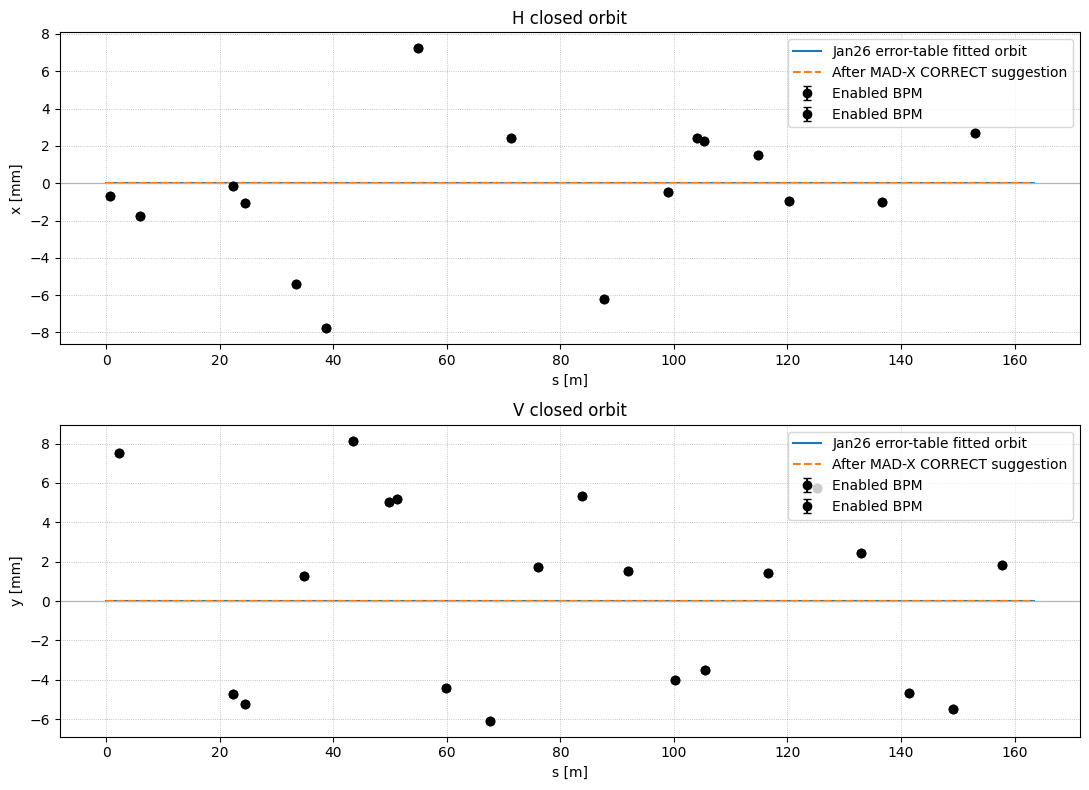

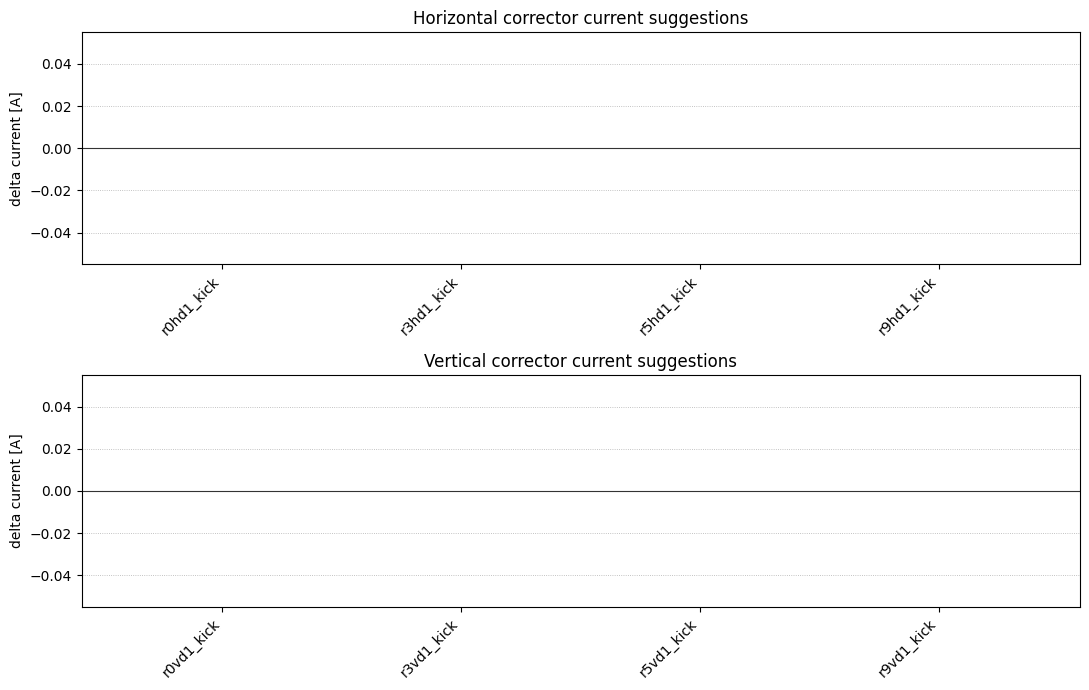

In [22]:
if RUN_FULL_MODEL and RUN_ORBIT_CORRECTION_EXAMPLE:
    h_correction = next(result.result for result in error_orbit_correction_snapshot.orbit_correction_results if result.plane == "H")
    v_correction = next(result.result for result in error_orbit_correction_snapshot.orbit_correction_results if result.plane == "V")

    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)
    plot_orbit_with_bpm(
        h_correction.measured_twiss_df,
        h_correction.bpm_measurements,
        plane="H",
        ax=axes[0],
        label="Jan26 error-table fitted orbit",
        title="Horizontal orbit before and after correction suggestion",
    )
    plot_orbit_with_bpm(
        h_correction.corrected_twiss_df,
        h_correction.bpm_measurements,
        plane="H",
        ax=axes[0],
        label="After MAD-X CORRECT suggestion",
        orbit_kwargs={"linestyle": "--"},
    )
    plot_orbit_with_bpm(
        v_correction.measured_twiss_df,
        v_correction.bpm_measurements,
        plane="V",
        ax=axes[1],
        label="Jan26 error-table fitted orbit",
        title="Vertical orbit before and after correction suggestion",
    )
    plot_orbit_with_bpm(
        v_correction.corrected_twiss_df,
        v_correction.bpm_measurements,
        plane="V",
        ax=axes[1],
        label="After MAD-X CORRECT suggestion",
        orbit_kwargs={"linestyle": "--"},
    )
    fig.tight_layout()

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)
    plot_corrector_suggestions(
        h_correction.correctors,
        ax=axes[0],
        value="delta_current_A",
        title="Horizontal corrector current suggestions",
    )
    plot_corrector_suggestions(
        v_correction.correctors,
        ax=axes[1],
        value="delta_current_A",
        title="Vertical corrector current suggestions",
    )
    fig.tight_layout()
else:
    print("Correction plots skipped. Keep RUN_FULL_MODEL and RUN_ORBIT_CORRECTION_EXAMPLE true to run them.")


In [23]:
# Dummy BPM match with its corresponding MAD-X matched orbit
if RUN_FULL_MODEL and RUN_ORBIT_CORRECTION_EXAMPLE and "measured_orbit_snapshot" in globals():
    correction_result = measured_orbit_snapshot.orbit_correction_results[0].result
    ax = plot_orbit_with_bpm(
        correction_result.measured_twiss_df,
        correction_result.bpm_measurements,
        plane="H",
        title="Dummy BPM measurements with MAD-X matched orbit",
    )
    display(measured_orbit_snapshot.table("orbit_correction_summary"))
    display(measured_orbit_snapshot.table("orbit_correction_bpm_comparison"))
else:
    print("Dummy BPM matched-orbit plot skipped. Set RUN_FULL_MODEL = True and RUN_ORBIT_CORRECTION_EXAMPLE = True to run this heavier example.")


Dummy BPM matched-orbit plot skipped. Set RUN_FULL_MODEL = True and RUN_ORBIT_CORRECTION_EXAMPLE = True to run this heavier example.


## B6. Orbit Plotting

For any model snapshot result, the orbit plot is usually `s` against `x_mm` and `y_mm`. This works for nominal or error-table model orbit results. Measured BPM tables should be plotted as BPM points, not as a continuous full-lattice orbit.


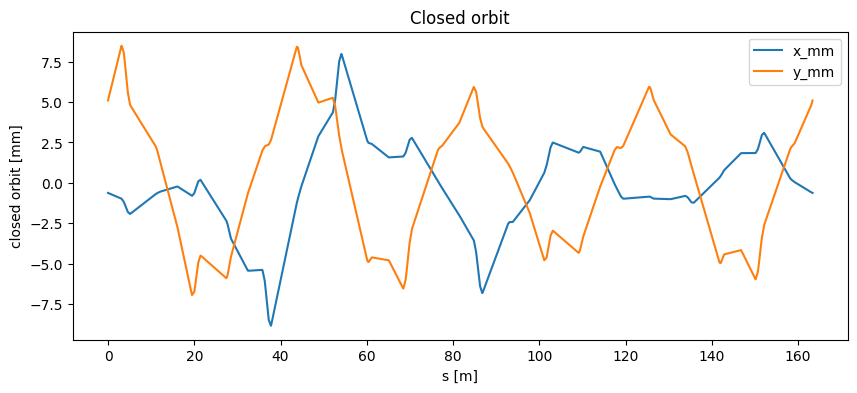

In [24]:
if RUN_FULL_MODEL:
    result_to_plot = error_orbit_snapshot if "error_orbit_snapshot" in globals() else nominal_orbit_snapshot
    ax = result_to_plot.table("orbit").plot(x="s", y=["x_mm", "y_mm"], figsize=(10, 4))
    ax.set_xlabel("s [m]")
    ax.set_ylabel("closed orbit [mm]")
    ax.set_title("Closed orbit")
else:
    print("Plot skipped because RUN_FULL_MODEL is False.")


## B7. Corrector Selection Interface

This table shape is useful when the orbit GUI later adds a selected-corrector panel. Correction outputs are model suggestions only; this repository must not write currents to the real machine.


In [25]:
selected_correctors = pd.DataFrame(
    [
        {"corrector": "r0hd1_kick", "plane": "H", "enabled": True},
        {"corrector": "r2hd1_kick", "plane": "H", "enabled": False},
    ]
)

normalise_corrector_table(selected_correctors, plane="H")


,corrector,plane,superperiod,enabled,initial_kick_rad,matched_kick_rad,delta_kick_rad,delta_kick_mrad,delta_current_A
0,r0hd1_kick,H,0,True,0.0,0.0,0.0,0.0,NaN
1,r2hd1_kick,H,2,False,0.0,0.0,0.0,0.0,NaN


<a id="part-c-streamlit-gui-for-envelope--aperture-loss-prediction"></a>

---

<div style="border-left: 6px solid #ef6c00; padding: 0.7em 1em; background: #fff4e8; margin: 1em 0;"><b>Part C: envelope and aperture group</b></div>


# Part C: Streamlit GUI For Envelope / Aperture Loss Prediction

This group needs orbit information because aperture margins are evaluated against the beam envelope and closed orbit. It does **not** need orbit correction.

A first GUI should let users choose:

- cycle time and tunes;
- emittance assumptions;
- momentum spread;
- sigma scale;
- whether to include aperture evaluation.

Then the GUI should display envelope, aperture-aligned and aperture-summary tables.

## C0. Packaged Source Aperture Data

The package includes the copied ISIS source aperture table used by the aperture layer. Loading this table is lightweight and does not require MAD-X.

In [26]:
source_aperture = read_source_aperture_csv()

print("rows:", len(source_aperture))
display(source_aperture[["name", "s", "aperture_x_mm", "aperture_y_mm", "aperture_source"]].head())


rows: 1740


,name,s,aperture_x_mm,aperture_y_mm,aperture_source
0,STT,0.00,87.959014,57.090587,source_spreadsheet
1,BF4,0.16,87.203259,58.666856,source_spreadsheet
2,BF5,0.26,86.730541,59.677213,source_spreadsheet
3,BF5,0.36,86.266733,60.700022,source_spreadsheet
4,BF6,0.39,86.129351,61.009197,source_spreadsheet


In [27]:
envelope_inputs = EnvelopeInputs(
    label="student envelope example",
    sigma_scale=1.0,
    dp_over_p=0.002,
    emittance_mode="geometric",
)

bare_envelope_config = SnapshotConfig(
    cycle_time_ms=0.0,
    requested_qx=4.31,
    requested_qy=3.83,
    lattice_folder=str(repo_root / "Dev" / "Lattice_Files" / "00_Simplified_Lattice"),
    output_dir=str(repo_root / "Dev" / "12_IO" / "student_runs" / "envelope_aperture" / "bare"),
    envelope_inputs=envelope_inputs,
    run_envelope=True,
    run_aperture=True,
)

if RUN_FULL_MODEL:
    envelope_snapshot = build_machine_snapshot(bare_envelope_config)
    print(envelope_snapshot.available_tables())
    display(envelope_snapshot.table("orbit_summary"))
    display(envelope_snapshot.table("envelope_summary"))
    display(envelope_snapshot.table("aperture_summary"))
else:
    print("Set RUN_FULL_MODEL = True to run MAD-X and calculate envelope/aperture tables.")
    print("This GUI will consume orbit, envelope, aperture_aligned and aperture_summary tables.")

['twiss', 'madx_summary', 'tune_summary', 'orbit', 'orbit_summary', 'corrector_settings', 'corrector_summary', 'warnings', 'envelope', 'envelope_summary', 'aperture', 'aperture_aligned', 'aperture_summary', 'source_aperture', 'source_aperture_aligned', 'source_aperture_summary']


,n_rows,max_abs_x_m,max_abs_y_m,rms_x_m,rms_y_m,max_orbit_radius_m,max_abs_x_mm,max_abs_y_mm,rms_x_mm,rms_y_mm,max_orbit_radius_mm
0,586,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,label,plane,sigma_scale,dp_over_p,emittance_mode,emit_x_geometric_m_rad,emit_y_geometric_m_rad,max_sigma_mm,max_sigma_name,max_sigma_s_m,max_plus_mm,max_plus_name,max_plus_s_m,min_minus_mm,min_minus_name,min_minus_s_m
0,student envelope example,x,1.0,0.002,geometric,0.0003,0.0003,76.499272,sp8_qf:1,135.788356,76.499272,sp8_qf:1,135.788356,-76.499272,sp8_qf:1,135.788356
1,student envelope example,y,1.0,0.002,geometric,0.0003,0.0003,70.830435,sp8_qdfr4:1,133.840656,70.830435,sp8_qdfr4:1,133.840656,-70.830435,sp8_qdfr4:1,133.840656


,label,name,s_m,limiting_plane,limiting_side,margin_min_m,margin_min_mm,aperture_source,aperture_alignment
0,nominal_0ms MAD-X aperture,drift_93:0,134.668506,y,y_plus,0.010694,10.694149,madx_aperture,s_interpolated


## C1. Non-Bare Orbit Envelope And Aperture

The envelope/aperture GUI also needs the same non-bare orbit idea used by the orbit group. Here the Jan26 survey error table is applied first, then the envelope and aperture margins are evaluated around that distorted closed orbit. This keeps the workflow realistic: aperture loss risk depends on both beam size and closed-orbit displacement.


In [28]:
# Non-bare envelope and aperture from Jan26 error table
nonbare_envelope_config = copy_snapshot_config(
    bare_envelope_config,
    snapshot_id="student_nonbare_envelope_aperture",
    label="student non-bare envelope/aperture",
    output_dir=str(repo_root / "Dev" / "12_IO" / "student_runs" / "envelope_aperture" / "jan26_error"),
    error_table_paths=[str(jan26_error_table)],
)

if RUN_FULL_MODEL:
    nonbare_envelope_snapshot = build_machine_snapshot(nonbare_envelope_config)
    display(nonbare_envelope_snapshot.table("orbit_summary"))
    display(nonbare_envelope_snapshot.table("envelope_summary"))
    display(nonbare_envelope_snapshot.table("aperture_summary"))
else:
    print("Non-bare envelope/aperture run skipped because RUN_FULL_MODEL is False.")


,n_rows,max_abs_x_m,max_abs_y_m,rms_x_m,rms_y_m,max_orbit_radius_m,max_abs_x_mm,max_abs_y_mm,rms_x_mm,rms_y_mm,max_orbit_radius_mm
0,586,0.008839,0.008486,0.003027,0.004241,0.009224,8.838513,8.486098,3.026537,4.241288,9.224284


,label,plane,sigma_scale,dp_over_p,emittance_mode,emit_x_geometric_m_rad,emit_y_geometric_m_rad,max_sigma_mm,max_sigma_name,max_sigma_s_m,max_plus_mm,max_plus_name,max_plus_s_m,min_minus_mm,min_minus_name,min_minus_s_m
0,student envelope example,x,1.0,0.002,geometric,0.0003,0.0003,76.570700,sp0_qf:1,5.098100,84.438764,sp3_qf:1,54.106946,-85.399033,sp2_qf:1,37.770664
1,student envelope example,y,1.0,0.002,geometric,0.0003,0.0003,70.866325,sp3_qdfr4:1,52.159246,79.304417,sp0_qdfr4:1,3.150400,-77.739830,sp1_qdfr4:1,19.486682


,label,name,s_m,limiting_plane,limiting_side,margin_min_m,margin_min_mm,aperture_source,aperture_alignment
0,student non-bare envelope/aperture MAD-X aperture,drift_5:0,3.97825,y,y_plus,0.00345,3.450005,madx_aperture,s_interpolated


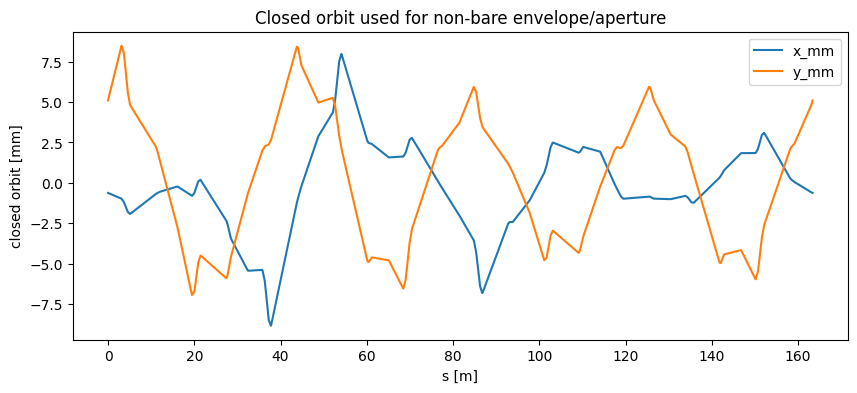

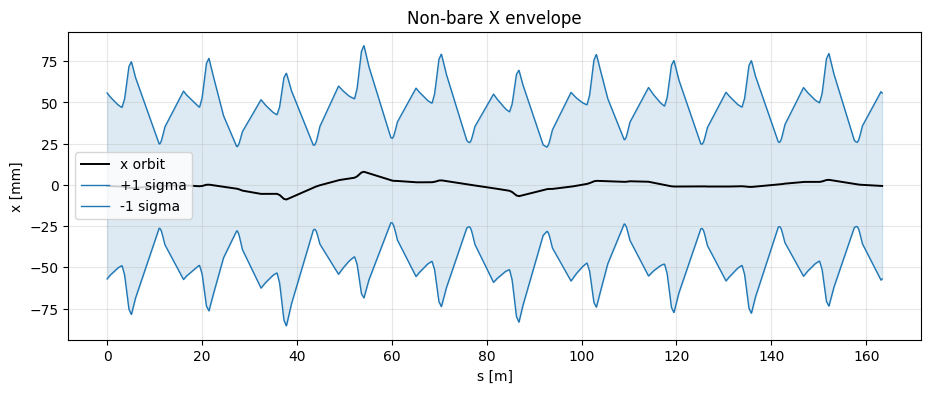

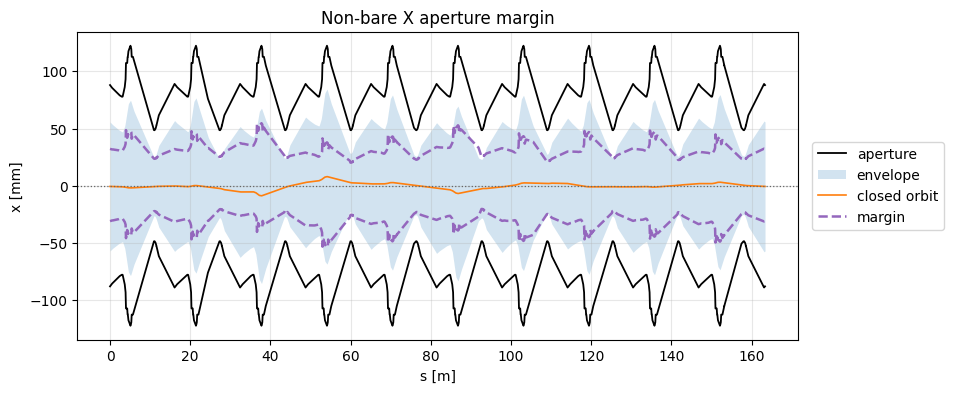

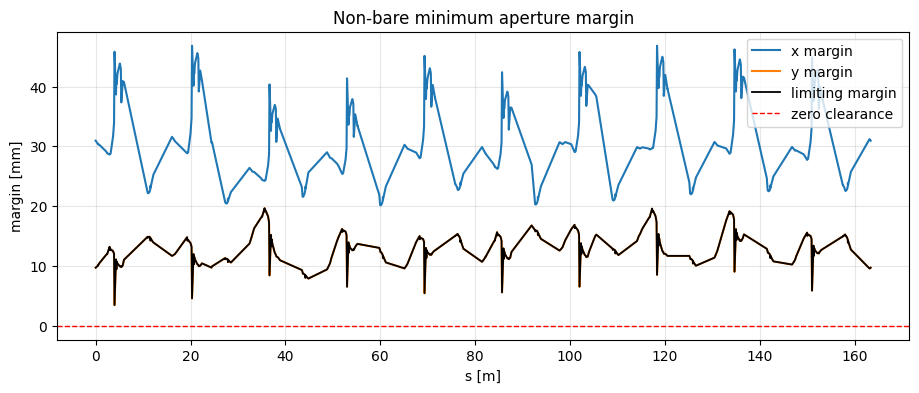

In [29]:
# Non-bare orbit, envelope and aperture plots
if RUN_FULL_MODEL:
    ax = nonbare_envelope_snapshot.table("orbit").plot(x="s", y=["x_mm", "y_mm"], figsize=(10, 4))
    ax.set_xlabel("s [m]")
    ax.set_ylabel("closed orbit [mm]")
    ax.set_title("Closed orbit used for non-bare envelope/aperture")
    ax = plot_envelope(nonbare_envelope_snapshot.envelope_result, plane="x", title="Non-bare X envelope")
    ax = plot_aperture_envelope_with_margin(nonbare_envelope_snapshot.aperture_result, plane="x", title="Non-bare X aperture margin")
    ax = plot_margin(nonbare_envelope_snapshot.aperture_result, title="Non-bare minimum aperture margin")
else:
    print("Non-bare envelope/aperture plots skipped because RUN_FULL_MODEL is False.")


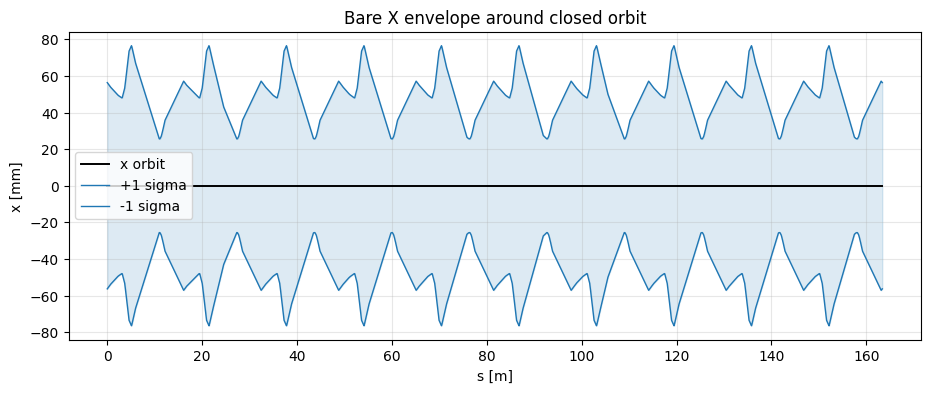

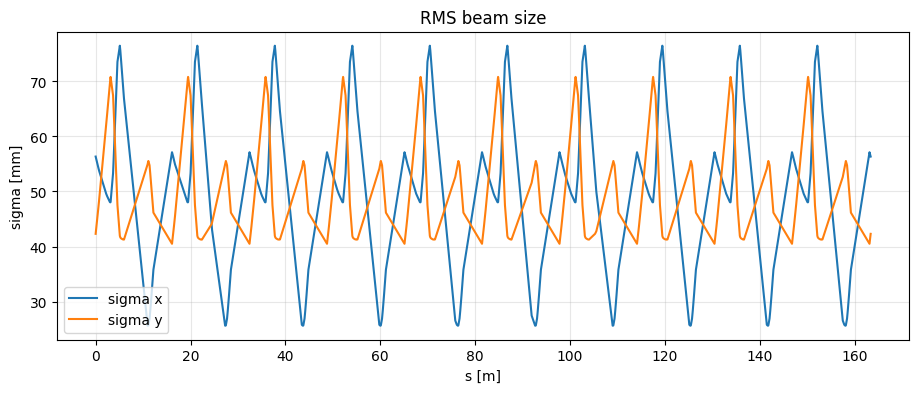

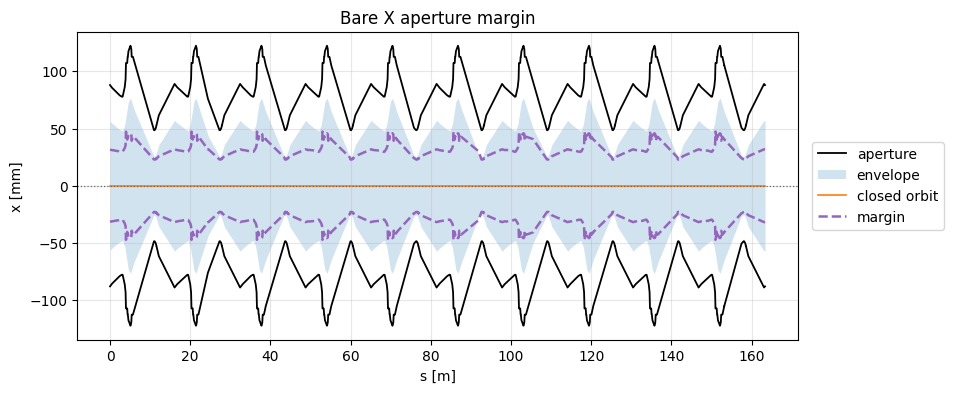

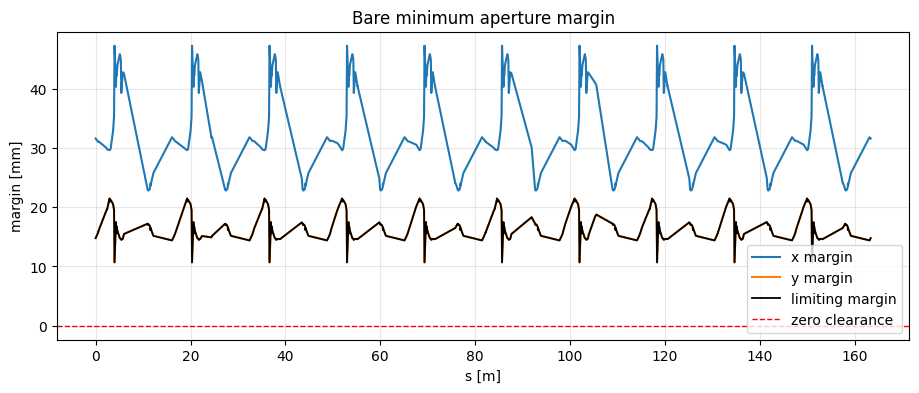

In [30]:
# Bare envelope and aperture visual checks
if RUN_FULL_MODEL:
    ax = plot_envelope(envelope_snapshot.envelope_result, plane="x", title="Bare X envelope around closed orbit")
    ax = plot_sigma(envelope_snapshot.envelope_result, title="RMS beam size")
    ax = plot_aperture_envelope_with_margin(envelope_snapshot.aperture_result, plane="x", title="Bare X aperture margin")
    ax = plot_margin(envelope_snapshot.aperture_result, title="Bare minimum aperture margin")
else:
    print("Envelope/aperture plots skipped because RUN_FULL_MODEL is False.")


In [31]:
if RUN_FULL_MODEL:
    aperture_table = envelope_snapshot.table("aperture_aligned")
    columns = [col for col in ["s", "x_plus_m", "x_minus_m", "aperture_x_m", "margin_x_m"] if col in aperture_table.columns]
    display(aperture_table[columns].head())
else:
    print("Example skipped because RUN_FULL_MODEL is False.")

,s,aperture_x_m,margin_x_m
0,0.00,0.087959,0.031608
1,0.00,0.087959,0.031608
2,0.16,0.087203,0.031438
3,0.36,0.086267,0.031223
4,0.39,0.086129,0.031192


## C2. Harmonic Envelope And Aperture

Harmonic tune settings change the trim-quadrupole pattern around the machine. For the GUI, treat harmonics as another optional input in `SnapshotConfig`. The plotting helper can compare the nominal and harmonic envelopes so students can see the effect visually.


In [32]:
# Harmonic envelope and aperture example
harmonic_envelope_config = copy_snapshot_config(
    bare_envelope_config,
    snapshot_id="student_harmonic_envelope_aperture",
    label="student harmonic envelope/aperture",
    output_dir=str(repo_root / "Dev" / "12_IO" / "student_runs" / "envelope_aperture" / "harmonic"),
    harmonics={"D7COS": 12},
)

if RUN_FULL_MODEL:
    harmonic_envelope_snapshot = build_machine_snapshot(harmonic_envelope_config)
    display(harmonic_envelope_snapshot.table("envelope_summary"))
    display(harmonic_envelope_snapshot.table("aperture_summary"))
else:
    print("Harmonic envelope/aperture run skipped because RUN_FULL_MODEL is False.")


,label,plane,sigma_scale,dp_over_p,emittance_mode,emit_x_geometric_m_rad,emit_y_geometric_m_rad,max_sigma_mm,max_sigma_name,max_sigma_s_m,max_plus_mm,max_plus_name,max_plus_s_m,min_minus_mm,min_minus_name,min_minus_s_m
0,student envelope example,x,1.0,0.002,geometric,0.0003,0.0003,78.131092,sp5_qf:1,86.77951,78.131092,sp5_qf:1,86.77951,-78.131092,sp5_qf:1,86.77951
1,student envelope example,y,1.0,0.002,geometric,0.0003,0.0003,74.631383,sp0_qdfr4:1,3.15040,74.631383,sp0_qdfr4:1,3.15040,-74.631383,sp0_qdfr4:1,3.15040


,label,name,s_m,limiting_plane,limiting_side,margin_min_m,margin_min_mm,aperture_source,aperture_alignment
0,student harmonic envelope/aperture MAD-X aperture,drift_5:0,3.97825,y,y_plus,0.007544,7.543691,madx_aperture,s_interpolated


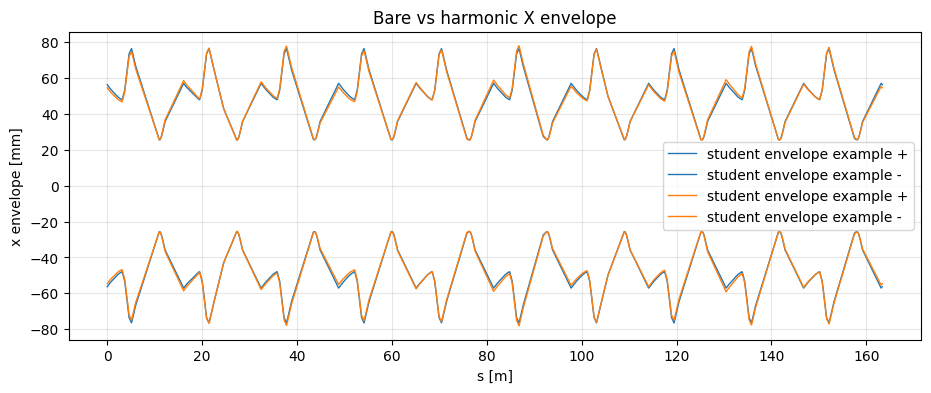

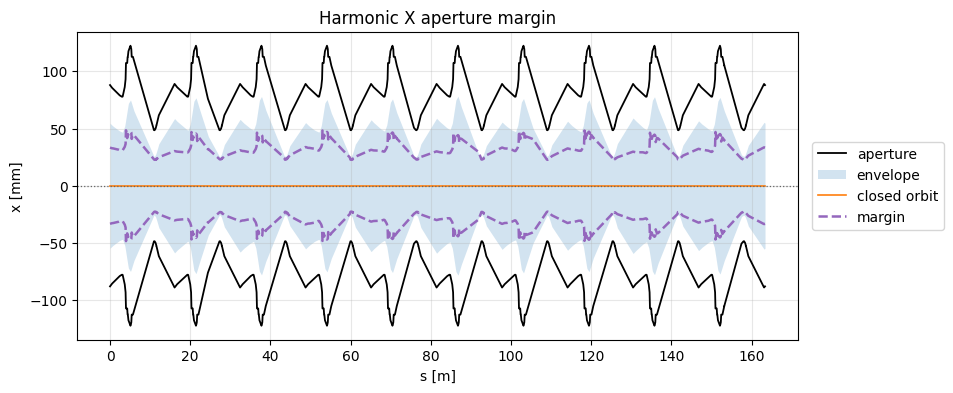

In [33]:
# Harmonic comparison plots
if RUN_FULL_MODEL:
    ax = plot_envelope_comparison(
        [envelope_snapshot.envelope_result, harmonic_envelope_snapshot.envelope_result],
        plane="x",
        title="Bare vs harmonic X envelope",
    )
    ax = plot_aperture_envelope_with_margin(
        harmonic_envelope_snapshot.aperture_result,
        plane="x",
        title="Harmonic X aperture margin",
    )
else:
    print("Harmonic comparison plots skipped because RUN_FULL_MODEL is False.")


A simple Streamlit page for this group could use:

```python
sigma_scale = st.number_input("Sigma scale", value=1.0)
dp_over_p = st.number_input("dp/p", value=0.002)
inputs = EnvelopeInputs(sigma_scale=sigma_scale, dp_over_p=dp_over_p)
config = SnapshotConfig(..., envelope_inputs=inputs, run_envelope=True, run_aperture=True)
result = build_machine_snapshot(config)
st.dataframe(result.table("aperture_summary"))
```

The page should not calculate aperture margins itself. It should call the backend and display backend tables.

<a id="part-d-streamlit-gui-for-working-point-programmes"></a>

---

<div style="border-left: 6px solid #6a1b9a; padding: 0.7em 1em; background: #f6effa; margin: 1em 0;"><b>Part D: working-point group</b></div>


# Part D: Streamlit GUI For Working-Point Programmes

This group does not need orbit, envelope or aperture. It needs time, set tunes, predicted MAD-X tunes, chromaticity and resonance inputs.

The main outputs are:

- `summary`: one row per snapshot;
- `tune_programme`: set and predicted tunes plus trim quadrupole values (the trim quadrupoles are red in the schematic diagram);
- `working_points`: points for tune diagrams;
- `resonance_lines`: resonance-line table;
- `resonance_proximity`: nearest resonance information.

## D1. Lightweight Tune Table Builders

The full working-point GUI should normally use snapshot-series outputs. These lower-level helpers are useful when a GUI already has a tune programme table and wants resonance inputs without running MAD-X in the parser.

In [34]:
lightweight_tune_input = pd.DataFrame(
    [
        {"cycle_time_ms": 0.0, "set_qx": 4.31, "set_qy": 3.83, "predicted_qx": 4.312, "predicted_qy": 3.828},
        {"cycle_time_ms": 0.5, "set_qx": 4.30, "set_qy": 3.82, "predicted_qx": 4.301, "predicted_qy": 3.819},
        {"cycle_time_ms": 1.0, "set_qx": 4.29, "set_qy": 3.81, "predicted_qx": 4.288, "predicted_qy": 3.812},
    ]
)

lightweight_programme = build_tune_programme_table(lightweight_tune_input, source="student_example")
lightweight_working_points = build_working_point_table(lightweight_programme)
lightweight_resonance_lines = generate_resonance_lines(xlims=(4.2, 4.4), ylims=(3.7, 3.9), orders=(1, 2, 3))
lightweight_resonance_proximity = evaluate_resonance_proximity(
    lightweight_working_points,
    resonance_lines=lightweight_resonance_lines,
    qx_column="predicted_qx",
    qy_column="predicted_qy",
)
lightweight_diagram_inputs = make_tune_diagram_inputs(
    lightweight_programme,
    xlims=(4.2, 4.4),
    ylims=(3.7, 3.9),
    orders=(1, 2, 3),
)

display(lightweight_programme)
display(lightweight_working_points[["cycle_time_ms", "set_qx", "set_qy", "predicted_qx", "predicted_qy"]])
display(lightweight_resonance_proximity.head())
print(lightweight_diagram_inputs.keys())


,cycle_time_ms,set_qx,set_qy,predicted_qx,predicted_qy,matched_qx,matched_qy,dqx,dqy,iqtf_A,iqtd_A,kqtf,kqtd,source,actual_qx,actual_qy
0,0.0,4.31,3.83,4.312,3.828,None,None,None,None,None,None,None,None,student_example,4.312,3.828
1,0.5,4.30,3.82,4.301,3.819,None,None,None,None,None,None,None,None,student_example,4.301,3.819
2,1.0,4.29,3.81,4.288,3.812,None,None,None,None,None,None,None,None,student_example,4.288,3.812


,cycle_time_ms,set_qx,set_qy,predicted_qx,predicted_qy
0,0.0,4.31,3.83,4.312,3.828
1,0.5,4.30,3.82,4.301,3.819
2,1.0,4.29,3.81,4.288,3.812


,point_index,cycle_time_ms,qx,qy,nearest_order,nearest_nx,nearest_ny,nearest_resonance_sum,nearest_label,nearest_systematic,signed_distance,absolute_distance
0,0,0.0,4.312,3.828,3,1,2,12,1Qx + 2Qy = 12,False,-0.014311,0.014311
1,1,0.5,4.301,3.819,3,1,2,12,1Qx + 2Qy = 12,False,-0.027280,0.027280
2,2,1.0,4.288,3.812,3,1,2,12,1Qx + 2Qy = 12,False,-0.039355,0.039355


dict_keys(['programme', 'working_points', 'resonance_lines', 'resonance_proximity', 'metadata'])


In [35]:
cycle_times_ms = [0.0, 0.5, 1.0]
qx_values = [4.31, 4.30, 4.29]
qy_values = [3.83, 3.82, 3.81]

working_point_base = SnapshotConfig(
    cycle_time_ms=0.0,
    requested_qx=4.31,
    requested_qy=3.83,
    lattice_folder=str(repo_root / "Dev" / "Lattice_Files" / "00_Simplified_Lattice"),
    output_dir=str(repo_root / "Dev" / "12_IO" / "student_runs" / "working_points"),
    run_envelope=False,
    run_aperture=False,
)

if RUN_FULL_MODEL:
    working_point_series = build_full_cycle_snapshot_series(
        cycle_times_ms,
        qx_values,
        qy_values,
        base_config=working_point_base,
        label="student_wp",
        output_dir=str(repo_root / "Dev" / "12_IO" / "student_runs" / "working_point_series"),
    )
    display(working_point_series.table("tune_programme"))
    display(working_point_series.table("working_points"))
    display(working_point_series.table("resonance_proximity").head())
else:
    print("Set RUN_FULL_MODEL = True to run the full working-point programme through MAD-X.")
    print("This GUI only needs series tables: tune_programme, working_points and resonance_proximity.")

,snapshot_index,snapshot_id,label,case,cycle_time_ms,set_qx,set_qy,predicted_qx,predicted_qy,dqx,dqy,iqtf_A,iqtd_A,kqtf,kqtd,source,actual_qx,actual_qy
0,0,student_wp_000,student_wp_00,student_wp,0.0,4.31,3.83,4.335953,3.830256,-4.955409,-4.935012,0.000000,-0.000000,0.000000,-0.000000,snapshot_series,4.335953,3.830256
1,1,student_wp_001,student_wp_01,student_wp,0.5,4.30,3.82,4.325721,3.820170,-4.880593,-4.894619,-6.108084,5.582443,-0.009555,0.008732,snapshot_series,4.325721,3.820170
2,2,student_wp_002,student_wp_02,student_wp,1.0,4.29,3.81,4.316848,3.811323,-4.817105,-4.859648,-12.867514,11.760179,-0.018142,0.016581,snapshot_series,4.316848,3.811323


,snapshot_index,snapshot_id,label,case,index,cycle_time_ms,set_qx,set_qy,predicted_qx,predicted_qy,actual_qx,actual_qy,predicted_minus_set_qx,predicted_minus_set_qy,actual_minus_set_qx,actual_minus_set_qy,source
0,0,student_wp_000,student_wp_00,student_wp,0,0.0,4.31,3.83,4.335953,3.830256,4.335953,3.830256,0.025953,0.000256,0.025953,0.000256,snapshot_series
1,1,student_wp_001,student_wp_01,student_wp,1,0.5,4.30,3.82,4.325721,3.820170,4.325721,3.820170,0.025721,0.000170,0.025721,0.000170,snapshot_series
2,2,student_wp_002,student_wp_02,student_wp,2,1.0,4.29,3.81,4.316848,3.811323,4.316848,3.811323,0.026848,0.001323,0.026848,0.001323,snapshot_series


,point_index,cycle_time_ms,qx,qy,nearest_order,nearest_nx,nearest_ny,nearest_resonance_sum,nearest_label,nearest_systematic,signed_distance,absolute_distance,snapshot_index,snapshot_id,label,case
0,0,0.0,4.335953,3.830256,3,1,2,12,1Qx + 2Qy = 12,False,-0.001581,0.001581,0,student_wp_000,student_wp_00,student_wp
1,1,0.5,4.325721,3.820170,4,2,-2,1,2Qx - 2Qy = 1,False,0.003925,0.003925,1,student_wp_001,student_wp_01,student_wp
2,2,1.0,4.316848,3.811323,4,2,-2,1,2Qx - 2Qy = 1,False,0.003907,0.003907,2,student_wp_002,student_wp_02,student_wp


<a id="part-e-saving-and-reloading-results"></a>

---

<div style="border-left: 6px solid #424242; padding: 0.7em 1em; background: #f1f1f1; margin: 1em 0;"><b>Part E: saved outputs and archives</b></div>


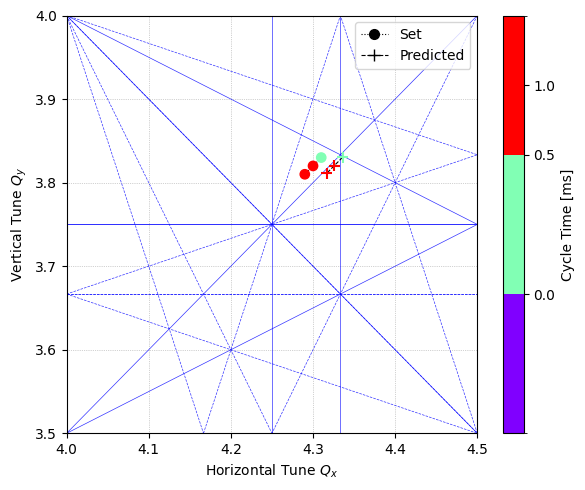

In [36]:
# Working-point tune diagram plot
if RUN_FULL_MODEL:
    diagram_inputs = {
        "programme": working_point_series.table("tune_programme"),
        "working_points": working_point_series.table("working_points"),
        "resonance_lines": working_point_series.table("resonance_lines"),
        "resonance_proximity": working_point_series.table("resonance_proximity"),
        "metadata": working_point_series.metadata.get("diagram", {}),
    }
    fig, ax = plot_tune_diagram_inputs(diagram_inputs)
else:
    print("Working-point tune diagram skipped because RUN_FULL_MODEL is False.")


# Part E: Saving And Reloading Results

The I/O boundary can save result bundles for a GUI archive. A bundle contains JSON config/metadata/manifests and CSV tables. Reading a bundle should not rerun MAD-X.

## E1. Config File Save/Load

A GUI can save a selected configuration before running the model. Config files are JSON-compatible records; large output tables stay separate in bundles.

In [37]:
config_dir = repo_root / "Dev" / "12_IO" / "student_runs" / "configs"
snapshot_config_path = config_dir / "basic_snapshot_config.json"
series_config_path = config_dir / "basic_series_config.json"

saved_snapshot_config_path = write_snapshot_config(basic_config, snapshot_config_path)
loaded_snapshot_config = read_snapshot_config(saved_snapshot_config_path)

basic_series_config = SnapshotSeriesConfig(
    snapshots=timepoint_configs,
    label="student_config_series",
    output_dir=str(repo_root / "Dev" / "12_IO" / "student_runs" / "config_series"),
)
series_record = series_config_to_record(basic_series_config)
round_trip_series_config = series_config_from_record(series_record)
saved_series_config_path = write_snapshot_series_config(basic_series_config, series_config_path)
loaded_series_config = read_snapshot_series_config(saved_series_config_path)

print(saved_snapshot_config_path)
print(loaded_snapshot_config.resolved_label())
print(saved_series_config_path)
print(round_trip_series_config.label, len(loaded_series_config.snapshots))


/home/hr/Repositories/optics_gui/Dev/12_IO/student_runs/configs/basic_snapshot_config.json
nominal_0ms
/home/hr/Repositories/optics_gui/Dev/12_IO/student_runs/configs/basic_series_config.json
student_config_series 2


In [38]:
if RUN_FULL_MODEL:
    bundle_dir = write_snapshot_bundle(orbit_snapshot)
    archived = read_run_bundle(bundle_dir)
    print(bundle_dir)
    print(archived.manifest["bundle_type"])
    print(archived.available_tables())
    display(archived.table("orbit_summary"))
else:
    print("Bundle save/load example skipped because RUN_FULL_MODEL is False.")

/home/hr/Repositories/optics_gui/Dev/12_IO/student_runs/orbit/20260713_132332_student_error_table_orbit/bundle
snapshot
['twiss', 'madx_summary', 'tune_summary', 'orbit', 'orbit_summary', 'corrector_settings', 'corrector_summary', 'warnings']


,n_rows,max_abs_x_m,max_abs_y_m,rms_x_m,rms_y_m,max_orbit_radius_m,max_abs_x_mm,max_abs_y_mm,rms_x_mm,rms_y_mm,max_orbit_radius_mm
0,586,0.008839,0.008486,0.003027,0.004241,0.009224,8.838513,8.486098,3.026537,4.241288,9.224284


<a id="final-notes-for-each-group"></a>

---

<div style="border-left: 6px solid #263238; padding: 0.7em 1em; background: #eef2f3; margin: 1em 0;"><b>Final notes</b></div>


# Final Notes For Each Group

## EPICS Archiver Group

Your job is to convert external data into clean tables and config fields. Do not run MAD-X in parsing code. Good outputs are `SnapshotConfig`, `SnapshotCorrectorSettings`, BPM DataFrames and timepoint config lists.

## Orbit GUI Group

Use `SnapshotConfig` and `build_machine_snapshot`. Display `orbit` and `orbit_summary`. Optional later work can add BPM/corrector selection and read-only correction suggestions.

## Envelope / Aperture Group

Use `EnvelopeInputs` plus `SnapshotConfig(run_envelope=True, run_aperture=True)`. Display `orbit`, `envelope`, `envelope_summary`, `aperture_aligned` and `aperture_summary`. You do not need orbit correction.

## Working-Point Group

Use timepoint tune data and snapshot series helpers. Display `tune_programme`, `working_points`, `resonance_lines` and `resonance_proximity`. You do not need orbit, envelope or aperture.

## Rule Of Thumb

Streamlit pages should collect user choices and display backend tables. Physics calculations, MAD-X execution and file-format parsing should stay in the package.